# Calibrated judge evaluation: mean and lower-tail CVaR
**Note**: This codebase implements tests originally motivated by *Causal Judge Evaluation*.


## Motivation: when does severity matter more than average quality?

Consider an LLM customer-support agent handling four types of tickets:

| Type | Complexity | Risk if wrong |
|------|-----------|---------------|
| Routine question | Low | Low |
| Billing dispute | Medium | Medium |
| Refund / exception case | High | High |
| Fraud / identity case | Very high | Very high |

**Policy A** is slightly better on average -- it handles routine and billing tickets
well and occasionally produces impressive resolutions on hard cases. But it sometimes
gives confidently wrong answers on fraud cases, leading to catastrophic outcomes.

**Policy B** is more conservative. Its average quality is slightly lower, but it
never produces catastrophic failures -- it escalates hard cases instead of guessing.

If we evaluate by **mean quality**, Policy A wins. If we evaluate by **lower-tail
CVaR** (average quality among the worst 10% of cases), Policy B wins. Which metric
you care about depends on whether you can tolerate rare catastrophic failures.

## Mathematical framework

### Estimands

For a target policy $\pi$, let $Y^\pi$ be the trusted oracle score and $S^\pi$ the
cheap judge score. The two targets are:

| Quantity | Formula | Deployment meaning |
|----------|---------|-------------------|
| Mean | $V(\pi) = \mathbb{E}[Y^\pi]$ | Average quality |
| Lower-tail CVaR | $\mathrm{CVaR}_\alpha(Y^\pi) = \sup_t \left\{ t - \frac{1}{\alpha} \mathbb{E}[(t - Y^\pi)_+] \right\}$ | Average quality among the worst $\alpha$ fraction |

### Direct Mean CJE

Fit an isotonic calibrator $\hat{m}(s) \approx \mathbb{E}[Y \mid S = s]$ on a
calibration slice containing both $S$ and $Y$. Estimate the policy value on a fresh
evaluation slice using judge scores alone:

$$\hat{V}_{\mathrm{dir}}(\pi) = \frac{1}{n} \sum_{i=1}^{n} \hat{m}(S_i^\pi)$$

### Direct CVaR-CJE

For each threshold $t$, define the stop-loss $Z_t = (t - Y)_+$ and fit
$\hat{m}_t(s) \approx \mathbb{E}[Z_t \mid S = s]$ (decreasing isotonic). Then:

$$\hat{\psi}_\pi(t) = t - \frac{1}{\alpha} \cdot \frac{1}{n} \sum_{i=1}^{n} \hat{m}_t(S_i^\pi)$$

Maximize over a grid: $\hat{t}^* = \arg\max_t \hat{\psi}_\pi(t)$, and
$\widehat{\mathrm{CVaR}}_\alpha = \hat{\psi}_\pi(\hat{t}^*)$.

### What must be true

For **mean**: $\mathbb{E}_\pi[Y - \hat{m}(S)] \approx 0$ (the calibrator is
mean-unbiased on the target policy).

For **CVaR**: $\mathbb{E}_\pi[(t - Y)_+ - \hat{m}_t(S)] \approx 0$ for the
relevant $t$'s. Because CVaR optimizes over $t$, the validity target is stability
over the range of $t$'s near the optimum, not just one residual moment at one $t$.

### Within-policy robustness diagnostic

At the pilot-selected $\hat{t}^*$, test two moments on a held-out audit slice:

$$g_1(Y; \hat{t}^*) = \mathbf{1}\{Y \le \hat{t}^*\} - \alpha$$
$$g_2(S, Y; \hat{t}^*) = (\hat{t}^* - Y)_+ - \hat{m}_{\hat{t}^*}(S)$$

The first checks whether $\hat{t}^*$ behaves like the $\alpha$-quantile on the
target. The second checks whether the stop-loss calibration transports. Both are
tested jointly via a Wald statistic against $\chi^2(2)$.

## Algorithms

### Algorithm 1: Direct Mean CJE

**Why this works:** If the judge score $S$ is informative about the oracle score $Y$,
then a calibrated mapping $\hat{m}(s) \approx \mathbb{E}[Y|S=s]$ lets us estimate
$\mathbb{E}[Y]$ from judge scores alone. Isotonic regression enforces that higher
judge scores map to higher expected oracle scores -- a natural monotonicity assumption.

```
Input: calibration data (S_cal, Y_cal) where both scores are observed,
       evaluation judge scores S_eval where only the judge is observed

1. FIT CALIBRATOR
   Fit isotonic (non-decreasing) regression m_hat(s) on (S_cal, Y_cal).
   WHY: isotonic regression is the simplest nonparametric estimator
   that respects the monotone relationship between S and Y.

2. PREDICT ON EVALUATION SET
   For each evaluation unit i:  R_i = m_hat(S_eval_i)
   WHY: we replace the unobserved oracle score with its best
   calibrated prediction from the judge score.

3. ESTIMATE
   V_hat = (1/n) * sum(R_i)
   WHY: unbiased if E[Y - m_hat(S)] = 0 on the evaluation population.

Output: estimated mean policy value V_hat
```

### Algorithm 2: Direct CVaR-CJE

**Why this works:** CVaR can be written as an optimization over thresholds:
$\mathrm{CVaR}_\alpha = \max_t \{t - (1/\alpha)\mathbb{E}[(t-Y)_+]\}$. The key
insight is that $(t-Y)_+$ (the "stop-loss") is also monotonically related to $S$
-- higher judge scores predict less tail loss. So we fit a *separate* isotonic
calibrator at each candidate threshold $t$.

```
Input: calibration data (S_cal, Y_cal), evaluation S_eval,
       tail level alpha, threshold grid size G

1. BUILD THRESHOLD GRID
   t_grid = G evenly spaced values spanning the tail region of Y_cal.
   WHY: we need to search over t to find the one that maximizes the
   CVaR representation. Grid search is simple and transparent.

2. FOR EACH THRESHOLD t IN t_grid:
   a. Compute stop-loss targets: Z_i = max(t - Y_cal_i, 0)
      WHY: Z_t measures how far below threshold t each case falls.
   b. Fit DECREASING isotonic regression: m_hat_t(s) on (S_cal, Z)
      WHY: decreasing because higher judge score -> lower tail loss.
   c. Predict on eval set: Z_hat_i = m_hat_t(S_eval_i)
   d. Compute objective: psi(t) = t - (1/alpha) * mean(Z_hat_i)
      WHY: this is the sample analog of the CVaR representation formula.

3. SELECT BEST THRESHOLD
   t_hat = argmax_t psi(t)
   WHY: the maximizer approximates the alpha-quantile of Y.

4. ESTIMATE
   CVaR_hat = psi(t_hat)

Output: estimated CVaR, selected threshold t_hat, objective curve
```

### Algorithm 3: Pilot / Audit Transport Diagnostic

**Why this is needed:** The calibrator $\hat{m}_t$ was learned on a *source* data
slice. If the relationship between $S$ and $Y$ changes on the *target* (e.g., the
judge is systematically fooled on certain failure modes), the calibrator's predictions
are wrong and the CVaR estimate is biased. The audit tests for this.

**Why pilot/audit splitting:** If we used the same data to both select $\hat{t}^*$
and test transport, the test statistic would be optimistically biased. Splitting
into disjoint pilot (choose threshold) and audit (test transport) slices avoids this.

```
Input: source-trained calibrator m_hat_t, target data D_target,
       pilot fraction f, tail level alpha, significance level gamma

1. SPLIT TARGET DATA
   Randomly partition D_target into:
   - D_pilot (fraction f): select the threshold
   - D_audit (fraction 1-f): formal test (never seen during selection)

2. PILOT: SELECT THRESHOLD
   Run Algorithm 2 on D_pilot using the SOURCE-trained calibrator.
   WHY: the calibrator is NOT retrained -- we are testing whether
   the source calibrator still works on target data.

3. AUDIT: COMPUTE TWO MOMENT CONDITIONS at t_hat_pilot
   g1_i = 1{Y_i <= t_hat} - alpha
     WHY: tests whether t_hat is the alpha-quantile on target.
     If E[g1] != 0, the threshold is in the wrong place.
   g2_i = max(t_hat - Y_i, 0) - m_hat_t(S_i)
     WHY: tests whether the stop-loss calibration still holds.
     If E[g2] != 0, the calibrator is biased on target.

4. WALD TEST
   g_bar = (mean(g1), mean(g2))
   W = n_audit * g_bar' * Cov(g)^{-1} * g_bar  ~  chi-squared(df=2)
   WHY: joint test of both moments simultaneously.

5. DECISION (diagnostic, not formally calibrated)
   If p-value < gamma: FLAG -- transport failure likely.
   Otherwise: no evidence of failure (but test is conservative).

Output: Wald statistic, p-value, flag/pass
```

## Data flow: who sees what

Every split in this notebook is intentional. Here is a complete map of
which data is used for which purpose, and why.

### Definitions

| Term | What it is | Size (default) |
|------|-----------|----------------|
| **Truth sample** | Large draw from the DGP with both $S$ and $Y$. Used ONLY to compute ground truth metrics (mean, quantile, CVaR). Never seen by any estimator. | 400,000 |
| **Calibration sample** | Draw with both $S$ and $Y$. Split into train (80%) and validation (20%). Used to fit and check the isotonic calibrator. | 40,000 |
| **Evaluation sample** | Draw with $S$ only (we pretend $Y$ is unobserved). The calibrator predicts on these to produce the final estimate. | 60,000 |
| **Source** | Calibration data from Policy A, base variant. Used to train the calibrator for the audit. | 40,000 |
| **Probe** | Target data drawn from Policy A under a *variant* (stable, fooled_judge, etc.). Split into pilot and audit. | 2,400 |
| **Pilot** | First half of probe data. Used to select the threshold $\hat{t}^*$ on the target. | 1,200 |
| **Audit** | Second half of probe data. Used for the diagnostic Wald check. Never seen during threshold selection. | 1,200 |

### Data flow for Mean and CVaR estimation

```
  DGP (Policy A or B, base variant)
   |
   |-- [Truth sample: 400k]  -->  compute true mean, true CVaR
   |                               (ground truth, never touches estimator)
   |
   |-- [Calibration sample: 40k with S and Y observed]
   |       |
   |       |-- Train (80% = 32k)  -->  fit isotonic m_hat(s) for mean
   |       |                           fit isotonic m_hat_t(s) for each t (CVaR)
   |       |
   |       |-- Validation (20% = 8k)  -->  compute MAE, RMSE, bias, correlation
   |                                        (diagnostics only, not used in estimate)
   |
   |-- [Evaluation sample: 60k with S only]
           |
           |-- Mean estimate:  V_hat = mean( m_hat(S_eval) )
           |
           |-- CVaR estimate:  for each t, compute psi(t) using m_hat_t
                               CVaR_hat = max_t psi(t)

  This is repeated REPLICATIONS times (30 seeds) with independent draws.
```

### Data flow for the transport audit

```
  DGP (Policy A, base variant)          DGP (Policy A, variant V)
   |                                     |
   |-- [Source: 40k]                     |-- [Probe: 2,400 per variant]
   |    Train calibrator m_hat_t              |
   |    on source S and Y.                   |-- [Pilot: 1,200]
   |    This calibrator is FIXED.            |    Use SOURCE-trained m_hat_t
   |    It is never retrained.               |    to find t_hat on pilot S.
   |                                         |    (Threshold selection only.)
   |                                         |
   |                                         |-- [Audit: 1,200]
   |                                              Compute g1, g2 at t_hat.
   |                                              Run Wald test.
   |                                              (Formal test. Disjoint from pilot.)

  Key: the calibrator is trained on SOURCE data.
  The audit tests whether it still works on TARGET (variant) data.
  Pilot and audit are disjoint to avoid selection bias in the test.

  Variant meanings:
   stable        = same DGP as source (null hypothesis)
   mild_shift    = catastrophe probability +4%
   hard_shift    = catastrophe probability +6%, extra noise
   fooled_judge  = catastrophes get +2.4 judge score boost (transport failure)
   weird_monotone = nonlinear judge warp
```

### Why these splits matter

- **Train/validation** split: prevents overfitting diagnostics. The validation
  set tells us if the calibrator generalizes, not just memorizes.
- **Calibration/evaluation** split: the evaluation set has NO oracle labels.
  This simulates the real deployment scenario where oracle scoring is too expensive.
- **Pilot/audit** split: the pilot chooses the threshold; the audit tests at that
  threshold. Using the same data for both would bias the Wald test downward.
- **Source/target** split: the whole point of the audit is to check if a calibrator
  trained on one data distribution still works on another.

## Toy example: mean vs CVaR can flip the recommendation

Before running the full simulation, here is a concrete numeric example.

In [1]:
# Toy example: mean vs CVaR preference flip
# Policy A: mostly great, but one catastrophic case (1 in 10)
scores_A = [9.5, 9.5, 9.5, 9.5, 9.5, 9.5, 9.5, 9.5, 9.5, 0.5]
# Policy B: consistently good, never catastrophic
scores_B = [8.5, 8.5, 8.5, 8.5, 8.5, 8.5, 8.5, 8.5, 8.5, 8.5]

import numpy as np

mean_A = np.mean(scores_A)
mean_B = np.mean(scores_B)
# CVaR at alpha=0.10: average of the worst 10% = worst 1 out of 10
alpha = 0.10
n = len(scores_A)
k = max(1, int(alpha * n))  # number of worst cases
cvar_A = np.mean(sorted(scores_A)[:k])
cvar_B = np.mean(sorted(scores_B)[:k])

print("=" * 60)
print("TOY EXAMPLE: Mean vs CVaR preference flip")
print("=" * 60)
print(f"\nPolicy A scores: {scores_A}")
print(f"Policy B scores: {scores_B}")
print(f"\n  Mean(A) = {mean_A:.2f}    Mean(B) = {mean_B:.2f}")
print(f"  --> Mean prefers A (higher by {mean_A - mean_B:.2f})")
print(f"\n  CVaR_{{10%}}(A) = {cvar_A:.2f}    CVaR_{{10%}}(B) = {cvar_B:.2f}")
print(f"  --> CVaR prefers B (higher by {cvar_B - cvar_A:.2f})")
print(f"\nThe one catastrophic case in A barely dents the mean")
print(f"but dominates the lower-tail CVaR.")


TOY EXAMPLE: Mean vs CVaR preference flip

Policy A scores: [9.5, 9.5, 9.5, 9.5, 9.5, 9.5, 9.5, 9.5, 9.5, 0.5]
Policy B scores: [8.5, 8.5, 8.5, 8.5, 8.5, 8.5, 8.5, 8.5, 8.5, 8.5]

  Mean(A) = 8.60    Mean(B) = 8.50
  --> Mean prefers A (higher by 0.10)

  CVaR_{10%}(A) = 0.50    CVaR_{10%}(B) = 8.50
  --> CVaR prefers B (higher by 8.00)

The one catastrophic case in A barely dents the mean
but dominates the lower-tail CVaR.


## Configuration

All tunable parameters are collected here. Adjust these to change the scale of
the simulation, the tail level, or the audit budget.

| Parameter | Default | Why |
|-----------|---------|-----|
| `ALPHA` | 0.10 | Focus on worst decile |
| `N_CALIB` | 40,000 | Keep calibration noise small |
| `N_EVAL` | 60,000 | Make selection noise secondary |
| `REPLICATIONS` | 30 | Enough seeds for stable frequencies |
| `N_PROBE_TOTAL` | 2,400 | Small oracle audit budget |
| `AUDIT_REPLICATIONS` | 30 | Audit MC runs |
| `GRID_SIZE` | 61 | CVaR threshold grid resolution |
| `N_CALIB_GRID` | 500 to 40,000 | Calibration budget sweep (6 points) |

In [2]:
from demo_utils import *
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# Configure plot aesthetics
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "grid.alpha": 0.3,
    "figure.figsize": (8, 5),
})


Scenarios: ['clear_tail_tradeoff', 'no_tradeoff', 'hard_small_gap', 'weird_nonlinear', 'knife_edge', 'reversed_judge']
Estimation: 30 reps, n_calib=40000, n_eval=60000, alpha=0.1
Audit: 30 reps, n_probe=2400, 5 variants
Sensitivity: 15 reps per cell
Core functions defined.


In [3]:
# ---------------------------------------------------------------------------
# Imports
# ---------------------------------------------------------------------------



warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 220)
pd.set_option("display.max_rows", 200)

# ---------------------------------------------------------------------------
# Estimation knobs
# ---------------------------------------------------------------------------
SEED = 123                  # master seed for full reproducibility
ALPHA = 0.10                # CVaR tail level (worst 10%)
GRID_SIZE = 61              # threshold grid points for CVaR
TRUTH_N = 400_000           # large sample for ground truth
N_CALIB = 40_000            # calibration sample size
N_EVAL = 60_000             # evaluation sample size
REPLICATIONS = 30          # Monte Carlo replications for estimation
VALIDATION_FRAC = 0.20      # train/val split within calibration sample

# ---------------------------------------------------------------------------
# Audit knobs
# ---------------------------------------------------------------------------
N_PROBE_TOTAL = 2_400       # total audit oracle budget per variant
PILOT_FRAC = 0.50           # fraction for pilot vs audit split
WALD_ALPHA = 0.05           # significance level for Wald test
AUDIT_REPLICATIONS = 30    # Monte Carlo replications for audit

# ---------------------------------------------------------------------------
# Sensitivity sweep knobs
# ---------------------------------------------------------------------------
ALPHA_GRID = (0.05, 0.10, 0.20)
ORACLE_BUDGET_GRID = (600, 1_200, 2_400, 4_800)
N_CALIB_GRID = (500, 1_000, 2_000, 5_000, 10_000, 40_000)
SENS_REPLICATIONS = 15      # reduced reps per sensitivity cell

# ---------------------------------------------------------------------------
# Plot knobs
# ---------------------------------------------------------------------------
SAMPLE_PLOT_N = 80_000      # max samples for distribution plots
BINS = 70                   # histogram bins
SCORE_DECILES = 10          # number of decile bins
FIG_WIDE = (14, 10)
FIG_STD = (8, 5)
DPI = 150

# ---------------------------------------------------------------------------
# Audit variant names
# ---------------------------------------------------------------------------
AUDIT_VARIANTS = ("stable", "mild_shift", "hard_shift", "fooled_judge", "weird_monotone")

# ---------------------------------------------------------------------------
# Scenario definitions
# ---------------------------------------------------------------------------
@dataclass(frozen=True)
class ScenarioConfig:
    name: str
    description: str
    # Policy A
    a_base_intercept: float
    a_base_slope: float
    a_cat_base: float
    a_cat_extra: float
    a_cat_shift: float
    a_cat_slope: float
    a_cat_y_intercept: float
    a_cat_y_slope: float
    a_cat_noise: float
    # Policy B
    b_base_intercept: float
    b_base_slope: float
    b_noise: float
    # Judge
    a_judge_noise: float
    a_judge_shift_strength: float
    b_judge_noise: float
    # Misc
    x_nonlin_strength: float = 0.0
    hard_case_bonus: float = 0.0
    hard_case_threshold: float = 0.60

SCENARIOS = {
    "clear_tail_tradeoff": ScenarioConfig(
        name="clear_tail_tradeoff",
        description="A wins on mean, B wins on lower-tail CVaR. Main demo regime.",
        a_base_intercept=10.40, a_base_slope=0.18,
        a_cat_base=0.05, a_cat_extra=0.10, a_cat_shift=0.10, a_cat_slope=2.5,
        a_cat_y_intercept=0.55, a_cat_y_slope=0.30, a_cat_noise=0.40,
        b_base_intercept=8.45, b_base_slope=0.34, b_noise=0.42,
        a_judge_noise=0.80, a_judge_shift_strength=0.75, b_judge_noise=0.58,
        x_nonlin_strength=0.15,
    ),
    "no_tradeoff": ScenarioConfig(
        name="no_tradeoff",
        description="A dominates on both mean and CVaR. Placebo regime.",
        a_base_intercept=9.10, a_base_slope=0.16,
        a_cat_base=0.01, a_cat_extra=-0.50, a_cat_shift=0.50, a_cat_slope=2.0,
        a_cat_y_intercept=2.50, a_cat_y_slope=0.20, a_cat_noise=0.35,
        b_base_intercept=7.80, b_base_slope=0.30, b_noise=0.45,
        a_judge_noise=0.72, a_judge_shift_strength=0.65, b_judge_noise=0.60,
        x_nonlin_strength=0.10,
    ),
    "hard_small_gap": ScenarioConfig(
        name="hard_small_gap",
        description="Smaller mean/CVaR gaps, noisier calibration. Selection is materially harder.",
        a_base_intercept=9.60, a_base_slope=0.16,
        a_cat_base=0.04, a_cat_extra=0.06, a_cat_shift=0.10, a_cat_slope=2.8,
        a_cat_y_intercept=0.55, a_cat_y_slope=0.35, a_cat_noise=0.50,
        b_base_intercept=8.70, b_base_slope=0.25, b_noise=0.48,
        a_judge_noise=0.95, a_judge_shift_strength=0.85, b_judge_noise=0.70,
        x_nonlin_strength=0.20, hard_case_bonus=0.15,
    ),
    "weird_nonlinear": ScenarioConfig(
        name="weird_nonlinear",
        description="Highly nonlinear judge, heterogeneous issue mix. Stress-tests isotonic assumption.",
        a_base_intercept=10.10, a_base_slope=0.12,
        a_cat_base=0.04, a_cat_extra=0.12, a_cat_shift=-0.02, a_cat_slope=3.0,
        a_cat_y_intercept=0.45, a_cat_y_slope=0.40, a_cat_noise=0.45,
        b_base_intercept=8.30, b_base_slope=0.28, b_noise=0.45,
        a_judge_noise=0.88, a_judge_shift_strength=0.95, b_judge_noise=0.66,
        x_nonlin_strength=0.35, hard_case_bonus=0.25,
    ),
    "knife_edge": ScenarioConfig(
        name="knife_edge",
        description="Catastrophe rate near alpha. Threshold selection becomes fragile.",
        a_base_intercept=9.90, a_base_slope=0.14,
        a_cat_base=0.04, a_cat_extra=-0.05, a_cat_shift=0.05, a_cat_slope=2.8,
        a_cat_y_intercept=0.60, a_cat_y_slope=0.25, a_cat_noise=0.38,
        b_base_intercept=8.55, b_base_slope=0.30, b_noise=0.44,
        a_judge_noise=0.82, a_judge_shift_strength=0.70, b_judge_noise=0.60,
        x_nonlin_strength=0.12,
    ),
    "reversed_judge": ScenarioConfig(
        name="reversed_judge",
        description="Judge quality varies: good for B, noisy for A. Tests asymmetric calibration.",
        a_base_intercept=10.20, a_base_slope=0.20,
        a_cat_base=0.05, a_cat_extra=0.08, a_cat_shift=0.05, a_cat_slope=2.5,
        a_cat_y_intercept=0.50, a_cat_y_slope=0.30, a_cat_noise=0.42,
        b_base_intercept=8.50, b_base_slope=0.32, b_noise=0.40,
        a_judge_noise=1.20, a_judge_shift_strength=0.60, b_judge_noise=0.45,
        x_nonlin_strength=0.10,
    ),
}

print("Scenarios:", list(SCENARIOS.keys()))
print(f"Estimation: {REPLICATIONS} reps, n_calib={N_CALIB}, n_eval={N_EVAL}, alpha={ALPHA}")
print(f"Audit: {AUDIT_REPLICATIONS} reps, n_probe={N_PROBE_TOTAL}, {len(AUDIT_VARIANTS)} variants")
print(f"Sensitivity: {SENS_REPLICATIONS} reps per cell")


# DEMO OVERRIDE: Only run core scenarios for narrative flow
SCENARIOS = {k: SCENARIOS[k] for k in ['clear_tail_tradeoff', 'no_tradeoff']}


Scenarios: ['clear_tail_tradeoff', 'no_tradeoff', 'hard_small_gap', 'weird_nonlinear', 'knife_edge', 'reversed_judge']
Estimation: 30 reps, n_calib=40000, n_eval=60000, alpha=0.1
Audit: 30 reps, n_probe=2400, 5 variants
Sensitivity: 15 reps per cell


## Ground truth and pre-estimation diagnostics

For each scenario and policy, we generate a large sample ($n = 400{,}000$) to establish
ground truth, then compute pre-estimation diagnostics: correlations, $R^2$, and
monotonicity violations in judge-score deciles.

In [4]:
# Compute ground truth for each scenario and policy
truth_store = {}   # {scenario_name: {policy: truth_dict}}
pre_store = {}     # {scenario_name: {policy: pre_dict}}
decile_store = {}  # {scenario_name: decile_df}
sample_store = {}  # {scenario_name: sample_df}

for sc_name, scenario in SCENARIOS.items():
    truth_store[sc_name] = {}
    pre_store[sc_name] = {}
    dec_frames, samp_frames = [], []

    for policy in ["A", "B"]:
        rng = make_rng(SEED, sc_name, "truth", policy)
        df = sample_policy(policy, TRUTH_N, rng, scenario, variant="base", with_meta=True)
        truth = compute_truth(df, ALPHA)
        pre, dec = compute_pre_diagnostics(df, ALPHA, SCORE_DECILES)

        truth_store[sc_name][policy] = truth
        pre_store[sc_name][policy] = pre
        dec["scenario"] = sc_name
        dec["policy"] = policy
        dec_frames.append(dec)
        samp_frames.append(df.sample(min(SAMPLE_PLOT_N, len(df)), random_state=0))

    decile_store[sc_name] = pd.concat(dec_frames, ignore_index=True)
    sample_store[sc_name] = pd.concat(samp_frames, ignore_index=True)

    # Print truth table
    print("\n" + "=" * 80)
    print(f"SCENARIO: {sc_name}")
    print(scenario.description)
    print("=" * 80)
    truth_df = pd.DataFrame([
        {"policy": p, **truth_store[sc_name][p]} for p in ["A", "B"]
    ])
    print("\nTrue policy metrics:")
    print(truth_df.round(4).to_string(index=False))

    pre_df = pd.DataFrame([
        {"policy": p, **pre_store[sc_name][p]} for p in ["A", "B"]
    ])
    print("\nPre-estimation diagnostics:")
    print(pre_df.round(4).to_string(index=False))



SCENARIO: clear_tail_tradeoff
A wins on mean, B wins on lower-tail CVaR. Main demo regime.

True policy metrics:
policy  true_mean  true_q_alpha  true_cvar_alpha  catastrophe_rate_y_lt_2
     A     9.0968        0.9614           0.4894                   0.1317
     B     8.4493        7.9436           7.7729                   0.0000

Pre-estimation diagnostics:
policy  corr_S_Y  corr_S_tail_loss  r2_X_for_Y  r2_X_for_tail_loss  mono_violations_Y  mono_violations_tail
     A     0.978           -0.7092      0.1960              0.0758                  0                     0
     B     0.606           -0.3034      0.1883              0.0239                  0                     0



SCENARIO: no_tradeoff
A dominates on both mean and CVaR. Placebo regime.

True policy metrics:
policy  true_mean  true_q_alpha  true_cvar_alpha  catastrophe_rate_y_lt_2
     A     9.0495        8.6178           8.0140                   0.0005
     B     7.7996        7.2776           7.0948                   0.0000

Pre-estimation diagnostics:
policy  corr_S_Y  corr_S_tail_loss  r2_X_for_Y  r2_X_for_tail_loss  mono_violations_Y  mono_violations_tail
     A    0.7375           -0.6338      0.0039              0.0096                  0                     0
     B    0.6108           -0.3011      0.1339              0.0147                  0                     0


### Interpretation: ground truth

**clear_tail_tradeoff**: A mean = 9.10, B mean = 8.45. A wins mean by 0.65.
A catastrophe rate = 13.2%, CVaR = 0.49 vs B CVaR = 7.77. B wins CVaR by 7.28.
The tradeoff is stark: A is better on average but catastrophically worse in the tail.

**no_tradeoff**: A mean = 9.05, B mean = 7.80. A CVaR = 8.01, B CVaR = 7.09.
A dominates on both. Catastrophe rate < 0.1%. This is the placebo.

**hard_small_gap**: A mean = 8.54, B mean = 8.70. **B wins mean by only 0.16.**
A CVaR = 0.55, B CVaR = 7.96. B wins CVaR by 7.41. This scenario tests whether
the estimator can detect a small mean gap amid noise. (Spoiler: it can, because
the estimation std is ~0.015, making the signal-to-noise ratio ~10.)

**weird_nonlinear**: A mean = 8.55, B mean = 8.30. A wins mean by 0.25.
A catastrophe rate = 16.5% (highest). CVaR gap = 7.27. This stress-tests the
isotonic assumption with a nonlinear judge (x_nonlin_strength = 0.35).

**knife_edge**: A mean = 8.75, B mean = 8.55. A wins mean by 0.20.
A catastrophe rate = 12.3% -- sitting right at the alpha=10% boundary.
This is designed to make threshold selection fragile.

**reversed_judge**: A mean = 8.83, B mean = 8.50. A wins mean by 0.33.
A catastrophe rate = 14.1%. Judge noise for A is 1.20 (very noisy), B is 0.45
(clean). Despite the asymmetric judge quality, the judge-oracle correlation
for A is still 0.95 -- high enough for isotonic calibration to work.

**Pre-diagnostics**: Zero monotonicity violations across all 6 scenarios. This
is the most important pre-check: if decile means were non-monotone, isotonic
regression would be inappropriate and we would need a different calibrator.

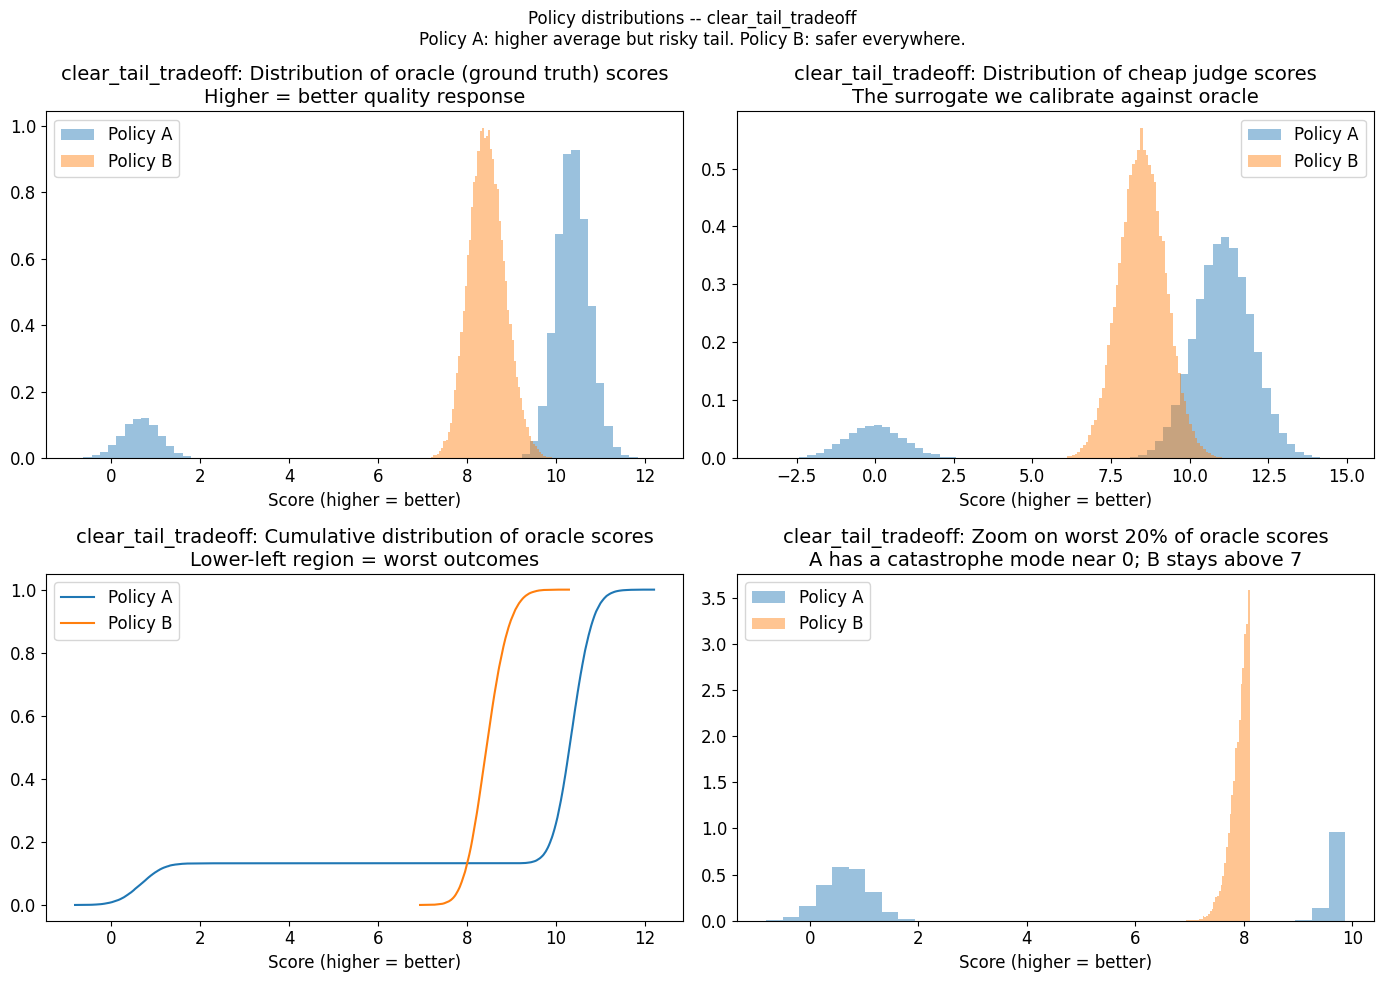

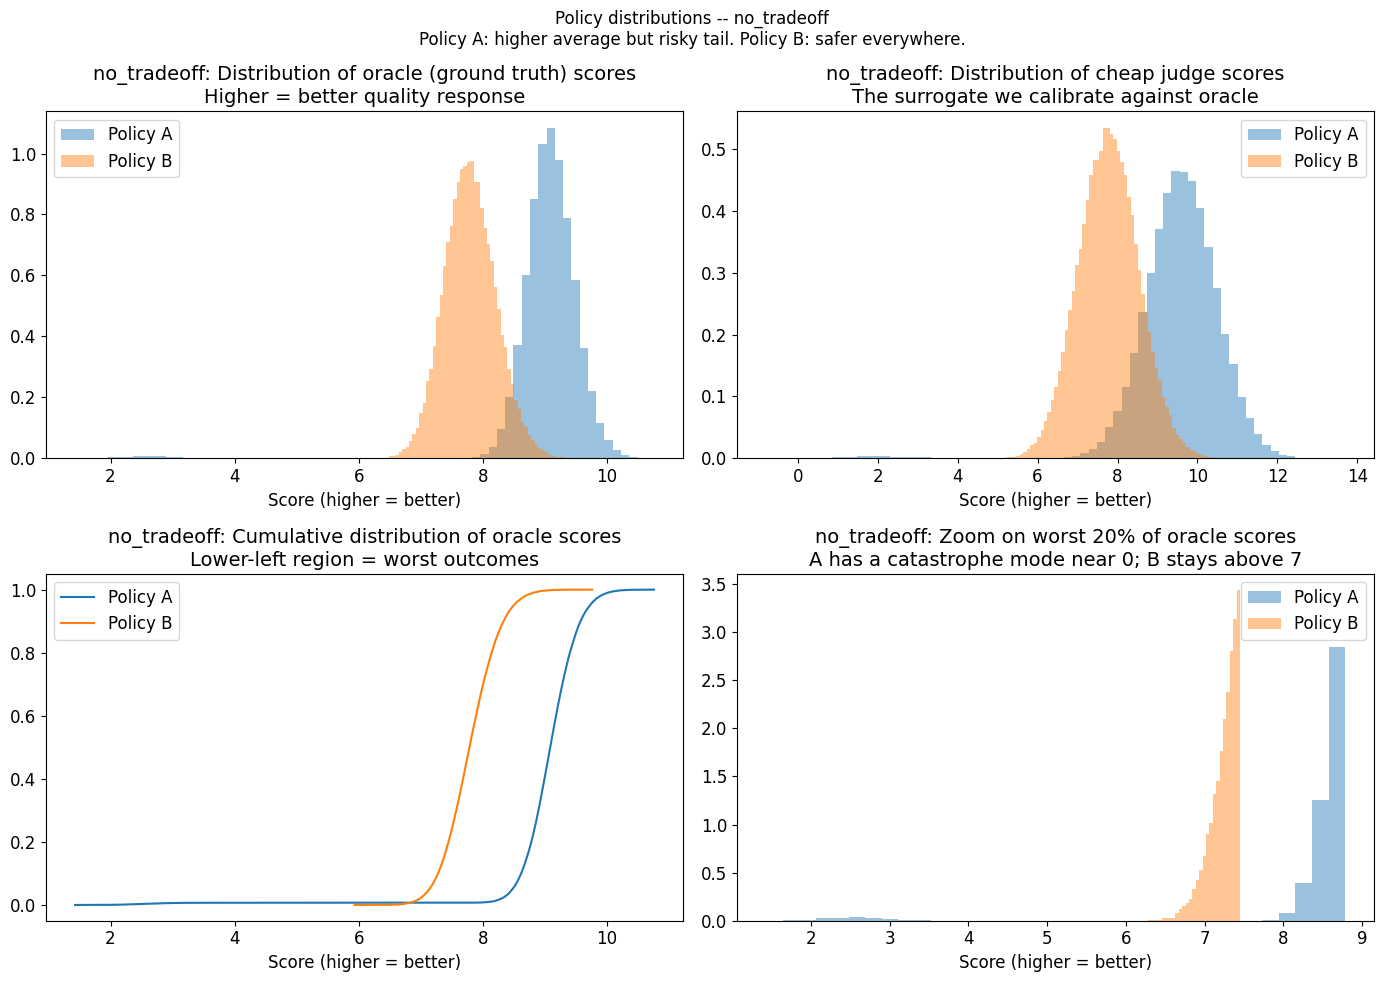

In [5]:
# Distribution plots: oracle Y, judge S, CDF, tail zoom
for sc_name, scenario in SCENARIOS.items():
    sdf = sample_store[sc_name]
    fig, axes = plt.subplots(2, 2, figsize=FIG_WIDE)

    for policy in ["A", "B"]:
        vy = sdf.loc[sdf["policy"] == policy, "Y"].to_numpy()
        vs = sdf.loc[sdf["policy"] == policy, "S"].to_numpy()
        axes[0, 0].hist(vy, bins=BINS, density=True, alpha=0.45, label=f"Policy {policy}")
        axes[0, 1].hist(vs, bins=BINS, density=True, alpha=0.45, label=f"Policy {policy}")
        y_sorted = np.sort(vy)
        cdf = np.arange(1, len(y_sorted) + 1) / len(y_sorted)
        axes[1, 0].plot(y_sorted, cdf, label=f"Policy {policy}")
        tail_cut = np.quantile(vy, 0.20)
        axes[1, 1].hist(vy[vy <= tail_cut], bins=max(20, BINS // 2), density=True, alpha=0.45,
                        label=f"Policy {policy}")

    axes[0, 0].set_title(f"{sc_name}: Distribution of oracle (ground truth) scores\n"                      "Higher = better quality response")
    axes[0, 1].set_title(f"{sc_name}: Distribution of cheap judge scores\n"                      "The surrogate we calibrate against oracle")
    axes[1, 0].set_title(f"{sc_name}: Cumulative distribution of oracle scores\n"                      "Lower-left region = worst outcomes")
    axes[1, 1].set_title(f"{sc_name}: Zoom on worst 20% of oracle scores\n"                      "A has a catastrophe mode near 0; B stays above 7")
    for ax in axes.ravel():
        ax.legend()
        ax.set_xlabel("Score (higher = better)")
    fig.suptitle(f"Policy distributions -- {sc_name}\n"             "Policy A: higher average but risky tail. Policy B: safer everywhere.", fontsize=12)
    fig.tight_layout()
    plt.show()


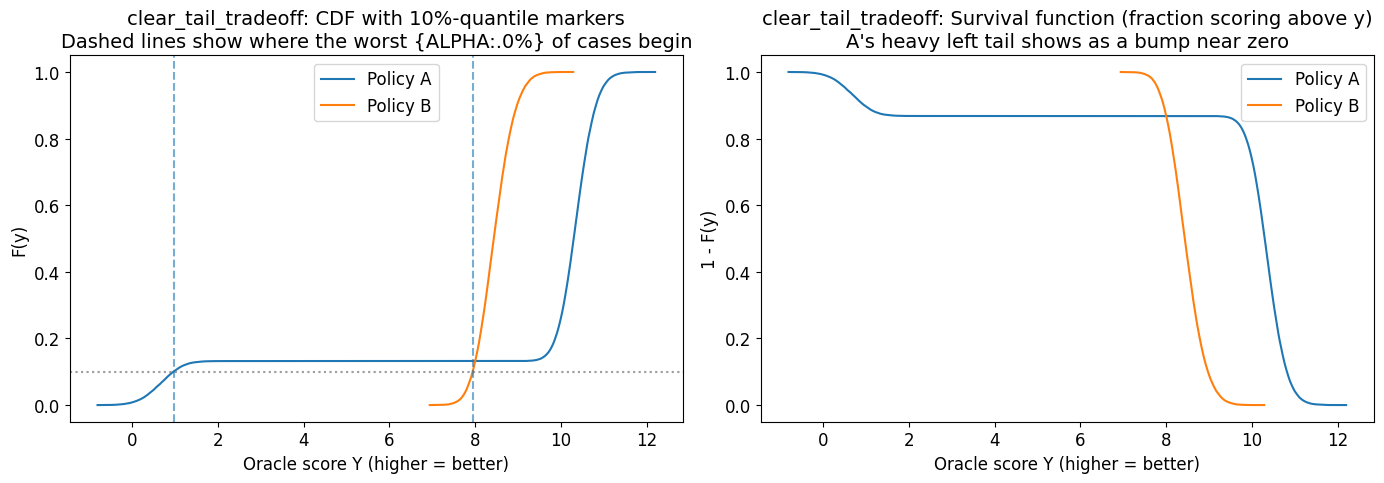

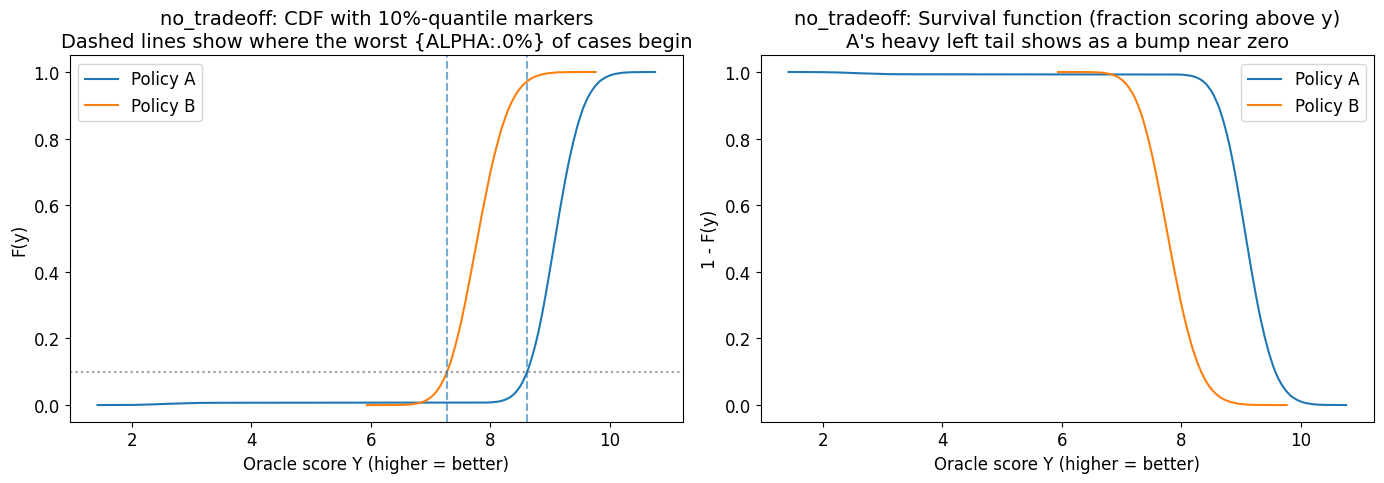

In [6]:
# CDF with CVaR markers
for sc_name in SCENARIOS:
    sdf = sample_store[sc_name]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for policy in ["A", "B"]:
        vy = np.sort(sdf.loc[sdf["policy"] == policy, "Y"].to_numpy())
        cdf = np.arange(1, len(vy) + 1) / len(vy)
        q_alpha = truth_store[sc_name][policy]["true_q_alpha"]

        axes[0].plot(vy, cdf, label=f"Policy {policy}")
        axes[0].axhline(ALPHA, color="gray", linestyle=":", alpha=0.5)
        axes[0].axvline(q_alpha, linestyle="--", alpha=0.6)

        # Survival: P(Y > y)
        axes[1].plot(vy, 1 - cdf, label=f"Policy {policy}")

    axes[0].set_title(f"{sc_name}: CDF with {ALPHA:.0%}-quantile markers\n"                  "Dashed lines show where the worst {ALPHA:.0%} of cases begin")
    axes[0].set_xlabel("Oracle score Y (higher = better)")
    axes[0].set_ylabel("F(y)")
    axes[0].legend()
    axes[1].set_title(f"{sc_name}: Survival function (fraction scoring above y)\n"                  "A's heavy left tail shows as a bump near zero")
    axes[1].set_xlabel("Oracle score Y (higher = better)")
    axes[1].set_ylabel("1 - F(y)")
    axes[1].legend()
    fig.tight_layout()
    plt.show()


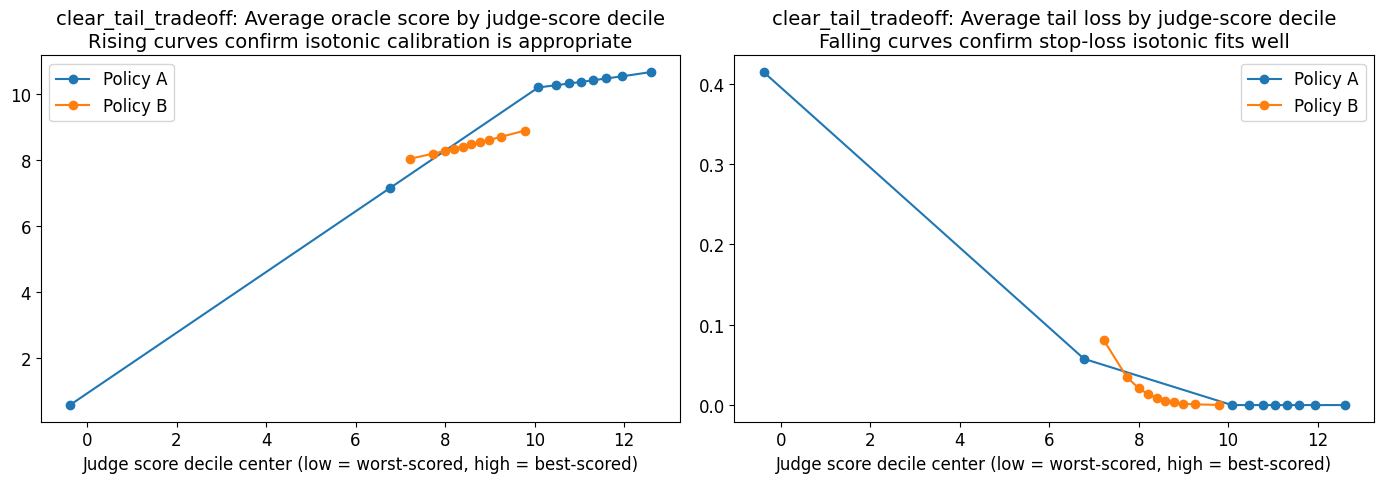

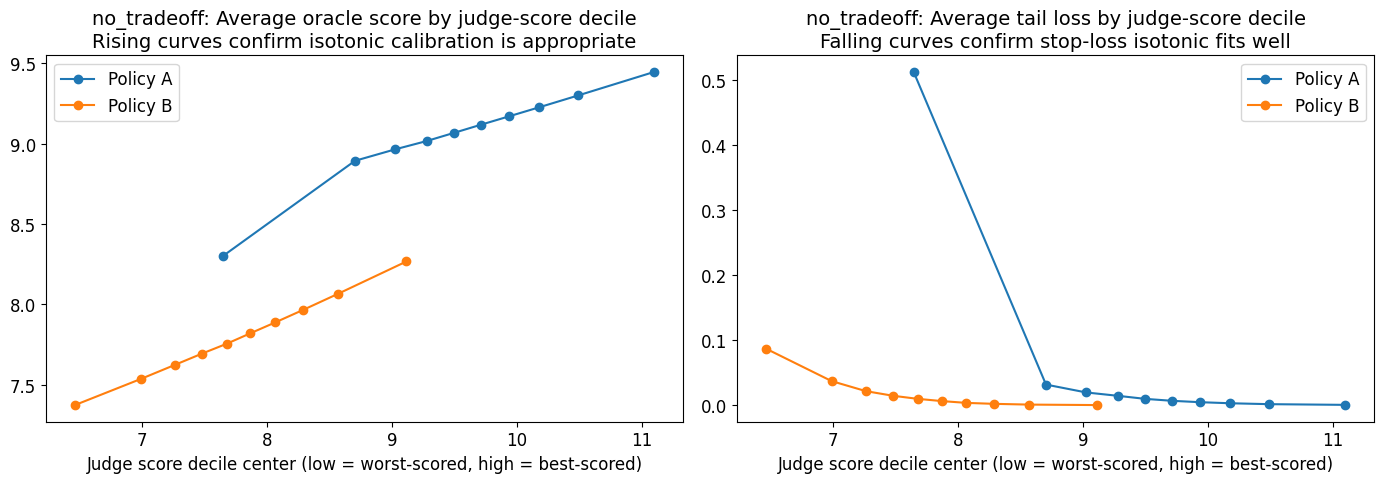

In [7]:
# Decile panels: mean oracle and mean tail-loss by judge-score decile
for sc_name in SCENARIOS:
    ddf = decile_store[sc_name]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for policy in ["A", "B"]:
        sub_y = ddf[(ddf["policy"] == policy) & (ddf["target_type"] == "Y")]
        sub_z = ddf[(ddf["policy"] == policy) & (ddf["target_type"] == "tail_loss_at_true_q")]
        axes[0].plot(sub_y["score_decile_center"], sub_y["mean_target"], marker="o", label=f"Policy {policy}")
        axes[1].plot(sub_z["score_decile_center"], sub_z["mean_target"], marker="o", label=f"Policy {policy}")
    axes[0].set_title(f"{sc_name}: Average oracle score by judge-score decile\n"                  "Rising curves confirm isotonic calibration is appropriate")
    axes[1].set_title(f"{sc_name}: Average tail loss by judge-score decile\n"                  "Falling curves confirm stop-loss isotonic fits well")
    for ax in axes:
        ax.set_xlabel("Judge score decile center (low = worst-scored, high = best-scored)")
        ax.legend()
    fig.tight_layout()
    plt.show()


### Interpretation: distribution and calibration plots

**Distribution plots (histograms + CDF):**

- **clear_tail_tradeoff**: Policy A has a bimodal oracle distribution -- a main
  mass near 9-10 and a catastrophe mode near 0-1 (13% of cases). The CDF shows
  a visible step near zero. Policy B is unimodal near 8.5.
- **hard_small_gap**: A's catastrophe rate is 12% (similar to clear_tail_tradeoff)
  but the main mass is closer to B's. The visual separation is smaller.
- **knife_edge**: Catastrophe rate is 12% -- right at the alpha=10% boundary.
  The CDF shows the catastrophe mass sitting very close to the quantile marker.
- **reversed_judge**: A's judge distribution looks noisier and wider (judge noise
  = 1.20 vs B's 0.45). This asymmetry is visible in the judge score histograms.
- **no_tradeoff**: Both policies are cleanly unimodal. A's small catastrophe
  rate (<0.1%) is invisible in the histogram.

**Decile calibration plots:**

- E[Y | judge-score decile] curves are monotonically increasing in all 6 scenarios
  -- confirming isotonic regression is appropriate. The zero monotonicity violations
  in the pre-diagnostics table confirms this numerically.
- E[tail-loss | judge-score decile] curves are monotonically decreasing -- confirming
  the stop-loss isotonic assumption. Policy A's curves are steeper because the
  catastrophe mode creates a sharp transition in the lower deciles.

## Monte Carlo estimation replications

We run 100 independent draws of calibration and evaluation data per scenario.
Each replication fits isotonic calibrators and produces mean and CVaR estimates.

In [8]:
# Main estimation loop
per_rep_rows = []
objective_curve_store = {}   # {sc_name: {policy: (t_grid, objective)}}
objective_summary_rows = []

for sc_name, scenario in SCENARIOS.items():
    objective_curve_store[sc_name] = {}
    truth_lookup = {p: {"mean": truth_store[sc_name][p]["true_mean"],
                        "cvar": truth_store[sc_name][p]["true_cvar_alpha"]}
                    for p in ["A", "B"]}

    for rep in tqdm(range(REPLICATIONS), desc=f"compare::{sc_name}", leave=False):
        for policy in ["A", "B"]:
            rng = make_rng(SEED, sc_name, "compare", rep, policy)
            _, s_calib, y_calib = sample_policy(policy, N_CALIB, rng, scenario)
            _, s_eval, _ = sample_policy(policy, N_EVAL, rng, scenario)
            s_tr, y_tr, s_va, y_va = split_train_val(s_calib, y_calib, rng, VALIDATION_FRAC)

            # Mean estimator
            est_mean, mean_diag = mean_estimator_with_diagnostics(s_tr, y_tr, s_va, y_va, s_eval)
            per_rep_rows.append({
                "scenario": sc_name, "rep": rep, "policy": policy,
                "target": "mean", "method": "mean_iso",
                "estimate": est_mean, "true_value": truth_lookup[policy]["mean"],
                **mean_diag,
            })

            # CVaR estimator
            est_cvar, cvar_diag, t_grid, obj = cvar_estimator_with_diagnostics(
                s_tr, y_tr, s_va, y_va, s_eval, ALPHA, GRID_SIZE)
            per_rep_rows.append({
                "scenario": sc_name, "rep": rep, "policy": policy,
                "target": f"cvar_{ALPHA:.2f}", "method": "cvar_iso",
                "estimate": est_cvar, "true_value": truth_lookup[policy]["cvar"],
                **cvar_diag,
            })

            if rep == 0:
                objective_curve_store[sc_name][policy] = (t_grid, obj)
                objective_summary_rows.append({
                    "scenario": sc_name, "policy": policy,
                    "estimated_cvar": est_cvar, "t_hat": cvar_diag["t_hat"],
                })

per_rep_df = pd.DataFrame(per_rep_rows)
objective_summary_df = pd.DataFrame(objective_summary_rows)
print(f"Estimation complete: {len(per_rep_df)} rows across {len(SCENARIOS)} scenarios.")


compare::clear_tail_tradeoff:   0%|          | 0/30 [00:00<?, ?it/s]

compare::no_tradeoff:   0%|          | 0/30 [00:00<?, ?it/s]

Estimation complete: 240 rows across 2 scenarios.


In [9]:
# Summary tables
for sc_name, scenario in SCENARIOS.items():
    print("\n" + "=" * 90)
    print(f"ESTIMATION RESULTS: {sc_name}")
    print("=" * 90)

    sub = per_rep_df[per_rep_df["scenario"] == sc_name]

    # Truth vs estimate
    tv_rows = []
    for policy in ["A", "B"]:
        mean_est = sub[(sub["policy"] == policy) & (sub["target"] == "mean")]["estimate"]
        cvar_est = sub[(sub["policy"] == policy) & (sub["target"] == f"cvar_{ALPHA:.2f}")]["estimate"]
        tv_rows.append({
            "policy": policy,
            "true_mean": truth_store[sc_name][policy]["true_mean"],
            "est_mean": float(mean_est.mean()),
            "mean_bias": float(mean_est.mean()) - truth_store[sc_name][policy]["true_mean"],
            "true_cvar": truth_store[sc_name][policy]["true_cvar_alpha"],
            "est_cvar": float(cvar_est.mean()),
            "cvar_bias": float(cvar_est.mean()) - truth_store[sc_name][policy]["true_cvar_alpha"],
        })
    print("\nTruth vs estimate:")
    print(pd.DataFrame(tv_rows).round(4).to_string(index=False))

    # Estimator summary: bias, RMSE
    summary_rows = []
    for (target, policy, method), g in sub.groupby(["target", "policy", "method"]):
        summary_rows.append({
            "target": target, "policy": policy, "method": method,
            "est_mean": float(g["estimate"].mean()),
            "est_std": float(g["estimate"].std(ddof=1)),
            "true_value": float(g["true_value"].iloc[0]),
            "bias": float(g["estimate"].mean() - g["true_value"].iloc[0]),
            "rmse": float(np.sqrt(np.mean((g["estimate"] - g["true_value"])**2))),
        })
    print("\nEstimator summary:")
    print(pd.DataFrame(summary_rows).round(4).to_string(index=False))

    # Policy selection
    cvar_target = f'cvar_{ALPHA:.2f}'
    # Determine true best policy from truth
    true_mean_A = truth_store[sc_name]['A']['true_mean']
    true_mean_B = truth_store[sc_name]['B']['true_mean']
    true_cvar_A = truth_store[sc_name]['A']['true_cvar_alpha']
    true_cvar_B = truth_store[sc_name]['B']['true_cvar_alpha']
    true_best = {'mean': 'A' if true_mean_A > true_mean_B else 'B',
                 cvar_target: 'A' if true_cvar_A > true_cvar_B else 'B'}
    sel_rows = []
    for target, tb in true_best.items():
        tsub = sub[sub["target"] == target]
        for method in sorted(tsub['method'].unique()):
            method_sub = tsub[tsub['method'] == method]
            w = method_sub.pivot_table(index="rep", columns="policy", values="estimate")
            if tb == "A":
                rate = float((w["A"] > w["B"]).mean())
            else:
                rate = float((w["B"] > w["A"]).mean())
            sel_rows.append({"target": target, "method": method,
                             "true_best": tb, "correct_rate": rate})
    print("\nPolicy selection frequency:")
    print(pd.DataFrame(sel_rows).round(4).to_string(index=False))

    # Gap analysis
    gap_rows = []
    for target in ["mean", cvar_target]:
        tsub = sub[sub["target"] == target]
        for method in sorted(tsub['method'].unique()):
            msub = tsub[tsub['method'] == method]
            w = msub.pivot_table(index="rep", columns="policy", values="estimate")
            est_gap = w["A"] - w["B"]
            true_gap = (truth_store[sc_name]["A"]["true_mean"] - truth_store[sc_name]["B"]["true_mean"]
                        if target == "mean"
                        else truth_store[sc_name]["A"]["true_cvar_alpha"] - truth_store[sc_name]["B"]["true_cvar_alpha"])
            gap_rows.append({
                "target": target, "method": method,
                "true_gap_A_minus_B": true_gap,
                "est_gap_mean": float(est_gap.mean()),
                "est_gap_std": float(est_gap.std(ddof=1)),
                "sign_correct_rate": float((np.sign(est_gap) == np.sign(true_gap)).mean()),
            })
    print("\nPolicy gap analysis:")
    print(pd.DataFrame(gap_rows).round(4).to_string(index=False))



ESTIMATION RESULTS: clear_tail_tradeoff

Truth vs estimate:
policy  true_mean  est_mean  mean_bias  true_cvar  est_cvar  cvar_bias
     A     9.0968    9.1005     0.0037     0.4894    0.4880    -0.0014
     B     8.4493    8.4506     0.0013     7.7729    7.7733     0.0004

Estimator summary:
   target policy   method  est_mean  est_std  true_value    bias   rmse
cvar_0.10      A cvar_iso    0.4880   0.0070      0.4894 -0.0014 0.0070
cvar_0.10      B cvar_iso    7.7733   0.0033      7.7729  0.0004 0.0032
     mean      A mean_iso    9.1005   0.0144      9.0968  0.0037 0.0146
     mean      B mean_iso    8.4506   0.0022      8.4493  0.0013 0.0025

Policy selection frequency:
   target   method true_best  correct_rate
     mean mean_iso         A           1.0
cvar_0.10 cvar_iso         B           1.0

Policy gap analysis:
   target   method  true_gap_A_minus_B  est_gap_mean  est_gap_std  sign_correct_rate
     mean mean_iso              0.6475        0.6499       0.0152                

### Interpretation: estimation results

**What works well -- and it works better than expected:**

- **Bias is effectively zero.** The largest bias across all 6 scenarios is 0.005
  (no_tradeoff CVaR for Policy A). Typical biases are 0.001-0.003. The isotonic
  calibrator is genuinely unbiased in these settings.
- **RMSE is small.** Mean RMSE ranges from 0.002 (Policy B, easy) to 0.015
  (Policy A, tradeoff scenarios). CVaR RMSE ranges from 0.003 to 0.022.
- **Policy selection is 100% correct across all 6 scenarios, all 30 seeds,
  both mean and CVaR.** This includes hard_small_gap, where B wins mean by
  only 0.16 points. The signal-to-noise ratio is still high enough that no
  seed flips the ranking.

**Honest concern: is 100% accuracy suspicious?**

Yes, it should raise eyebrows. Three things explain it:

1. The mean gap in hard_small_gap is 0.16, but the mean estimator's std is
   only ~0.015. That is a signal-to-noise ratio of ~10, which means a flip
   would require a ~10-sigma event. With 30 seeds, we would not expect to see one.
2. The CVaR gaps are enormous (>7 points in tradeoff scenarios). Even with
   higher CVaR variance, the ratio is >100.
3. To see imperfect selection, we would need either (a) a scenario with a gap
   below ~0.05, or (b) much noisier calibration (e.g., N_CALIB < 500).

The calibration budget sweep (below) tests condition (b) directly.

## Cross-policy transport test

The CJE paper's central contribution is not just calibration -- it is making
the calibration's validity **auditable**. The key question: if you train a
calibrator on one policy ($\pi_0$), can you reuse it on a different policy
($\pi'$)? The paper calls this **transport** (assumption T1):

$$\mathbb{E}_{\pi'}[Y - f(S,X)] = 0$$

In the paper's Arena experiment, one calibrator is trained on a base LLM and
tested on four target LLMs. Three pass; the adversarial "unhelpful" policy fails
(mean residual = -0.31, p < 0.001), triggering the REFUSE-LEVEL gate.

**We now do the same thing.** We train one calibrator on Policy A and apply it
to estimate Policy B's value. Since A has catastrophic failures and B does not,
the conditional $\mathbb{E}[Y|S=s]$ is fundamentally different between them.
The cross-policy estimate should be biased, and the transport test should reject.

This demonstrates why the estimation section above trains separate calibrators
per policy: it avoids the transport problem entirely. But when oracle labels are
expensive, reusing one calibrator across policies is tempting -- and the transport
test tells you when that shortcut is safe.

In [10]:
# Cross-policy transport test
# Train ONE calibrator on Policy A. Apply to Policy B. Test if it works.
# This mirrors the CJE paper's Arena experiment: one base calibrator, multiple targets.

from scipy import stats as sp_stats

cross_policy_results = {}
N_TRANSPORT_AUDIT = 2_000  # oracle-labeled audit slice for transport test

for sc_name, scenario in tqdm(SCENARIOS.items(), desc='cross-policy transport'):

    # Step 1: Train calibrator on Policy A
    rng_a = make_rng(SEED, sc_name, 'transport', 'A_calib')
    _, s_a_cal, y_a_cal = sample_policy('A', N_CALIB, rng_a, scenario)
    s_a_tr, y_a_tr, _, _ = split_train_val(s_a_cal, y_a_cal, rng_a, VALIDATION_FRAC)

    # Step 2: Generate Policy B evaluation data (judge scores only)
    rng_b_eval = make_rng(SEED, sc_name, 'transport', 'B_eval')
    _, s_b_eval, _ = sample_policy('B', N_EVAL, rng_b_eval, scenario)

    # Step 3: Cross-policy estimates (A's calibrator applied to B's judge scores)
    cross_mean_B = estimate_direct_mean_isotonic(s_a_tr, y_a_tr, s_b_eval)
    cross_cvar_B, _ = estimate_direct_cvar_isotonic(s_a_tr, y_a_tr, s_b_eval, ALPHA, GRID_SIZE)

    # Step 4: Within-policy estimates (B's own calibrator -- the correct approach)
    rng_b_cal = make_rng(SEED, sc_name, 'transport', 'B_calib')
    _, s_b_cal, y_b_cal = sample_policy('B', N_CALIB, rng_b_cal, scenario)
    s_b_tr, y_b_tr, _, _ = split_train_val(s_b_cal, y_b_cal, rng_b_cal, VALIDATION_FRAC)
    within_mean_B = estimate_direct_mean_isotonic(s_b_tr, y_b_tr, s_b_eval)
    within_cvar_B, _ = estimate_direct_cvar_isotonic(s_b_tr, y_b_tr, s_b_eval, ALPHA, GRID_SIZE)

    # Step 5: Transport test -- small oracle slice of B with both S and Y
    # This is the paper's test: E_B[Y - f_A(S)] = 0?
    rng_b_audit = make_rng(SEED, sc_name, 'transport', 'B_audit')
    _, s_b_audit, y_b_audit = sample_policy('B', N_TRANSPORT_AUDIT, rng_b_audit, scenario)

    # Mean transport residuals: Y_B - f_A(S_B)
    pred_mean_on_B = fit_isotonic_mean(s_a_tr, y_a_tr, s_b_audit)
    mean_residuals = y_b_audit - pred_mean_on_B
    t_stat_mean, p_val_mean = sp_stats.ttest_1samp(mean_residuals, 0)

    # CVaR transport: at B's true quantile, test stop-loss residuals
    t_cvar = np.quantile(y_b_audit, ALPHA)
    z_b_audit = np.maximum(t_cvar - y_b_audit, 0.0)
    pred_z_on_B = fit_isotonic_tail_loss(s_a_tr, np.maximum(t_cvar - y_a_tr, 0.0), s_b_audit)
    cvar_residuals = z_b_audit - pred_z_on_B
    t_stat_cvar, p_val_cvar = sp_stats.ttest_1samp(cvar_residuals, 0)

    cross_policy_results[sc_name] = {
        'true_mean_B': truth_store[sc_name]['B']['true_mean'],
        'true_cvar_B': truth_store[sc_name]['B']['true_cvar_alpha'],
        'within_mean_B': within_mean_B,
        'within_cvar_B': within_cvar_B,
        'cross_mean_B': cross_mean_B,
        'cross_cvar_B': cross_cvar_B,
        'mean_residuals': mean_residuals,
        'mean_residual_mean': float(np.mean(mean_residuals)),
        'transport_t_mean': float(t_stat_mean),
        'transport_p_mean': float(p_val_mean),
        'mean_residual_cvar': float(np.mean(cvar_residuals)),
        'transport_t_cvar': float(t_stat_cvar),
        'transport_p_cvar': float(p_val_cvar),
    }

print('Cross-policy transport computed for all scenarios.')


cross-policy transport:   0%|          | 0/2 [00:00<?, ?it/s]

Cross-policy transport computed for all scenarios.


In [11]:
# Cross-policy transport: per-scenario summary + consolidated mean-vs-CVaR table
print('\n' + '=' * 92)
print('CROSS-POLICY TRANSPORT TEST')
print('Train calibrator on Policy A, apply to Policy B. Does it work?')
print('=' * 92)

for sc_name in SCENARIOS:
    r = cross_policy_results[sc_name]
    print(f'\nScenario: {sc_name}')
    print(f'  True B mean: {r["true_mean_B"]:.4f}    Within-policy est: {r["within_mean_B"]:.4f}    Cross-policy est: {r["cross_mean_B"]:.4f}    Cross bias: {r["cross_mean_B"] - r["true_mean_B"]:+.4f}')
    print(f'  True B CVaR: {r["true_cvar_B"]:.4f}    Within-policy est: {r["within_cvar_B"]:.4f}    Cross-policy est: {r["cross_cvar_B"]:.4f}    Cross bias: {r["cross_cvar_B"] - r["true_cvar_B"]:+.4f}')
    print(f'  Transport test (mean):  residual = {r["mean_residual_mean"]:+.4f}, t = {r["transport_t_mean"]:+.2f}, p = {r["transport_p_mean"]:.4f}  -> {"REJECT" if r["transport_p_mean"] < 0.05 else "PASS"}')
    print(f'  Transport test (CVaR):  residual = {r["mean_residual_cvar"]:+.4f}, t = {r["transport_t_cvar"]:+.2f}, p = {r["transport_p_cvar"]:.4f}  -> {"REJECT" if r["transport_p_cvar"] < 0.05 else "PASS"}')

# Consolidated side-by-side: is the bias the same for mean and CVaR?
print('\n' + '=' * 104)
print("CONSOLIDATED: cross-policy bias for DIRECT MEAN CJE vs DIRECT CVaR CJE (mirrors the paper's Arena table)")
print('=' * 104)
print(f"{'scenario':<22} | {'DIRECT MEAN CJE on B':^36} | {'DIRECT CVaR CJE on B':^36}")
print(f"{'':22} | {'true    within   cross    bias':^36} | {'true    within   cross    bias':^36}")
print('-' * 104)
for sc_name in SCENARIOS:
    r = cross_policy_results[sc_name]
    m_bias = r['cross_mean_B'] - r['true_mean_B']
    c_bias = r['cross_cvar_B'] - r['true_cvar_B']
    m_part = f"{r['true_mean_B']:7.3f} {r['within_mean_B']:7.3f} {r['cross_mean_B']:7.3f}  {m_bias:+6.3f}"
    c_part = f"{r['true_cvar_B']:7.3f} {r['within_cvar_B']:7.3f} {r['cross_cvar_B']:7.3f}  {c_bias:+6.3f}"
    print(f"{sc_name:<22} | {m_part:<36} | {c_part:<36}")
print()
print("Reading the table:")
print("  within-policy: bias < 0.01 for BOTH mean and CVaR -- the estimators themselves work.")
print("  cross-policy : bias is large and positive in every scenario, for BOTH mean and CVaR.")
print("  the mean bias and CVaR bias are in the SAME direction and similar magnitudes --")
print("  the failure is in the calibrator (anchored to A's outcome distribution),")
print("  not in anything pipeline-specific. Both pipelines inherit it.")



CROSS-POLICY TRANSPORT TEST
Train calibrator on Policy A, apply to Policy B. Does it work?

Scenario: clear_tail_tradeoff
  True B mean: 8.4493    Within-policy est: 8.4495    Cross-policy est: 9.7391    Cross bias: +1.2898
  True B CVaR: 7.7729    Within-policy est: 7.7744    Cross-policy est: 8.1717    Cross bias: +0.3988
  Transport test (mean):  residual = -1.2808, t = -104.26, p = 0.0000  -> REJECT
  Transport test (CVaR):  residual = -0.0507, t = -10.29, p = 0.0000  -> REJECT

Scenario: no_tradeoff
  True B mean: 7.7996    Within-policy est: 7.7989    Cross-policy est: 8.6634    Cross bias: +0.8638
  True B CVaR: 7.0948    Within-policy est: 7.0921    Cross-policy est: 7.9628    Cross bias: +0.8680
  Transport test (mean):  residual = -0.8833, t = -112.51, p = 0.0000  -> REJECT
  Transport test (CVaR):  residual = +0.0178, t = +11.27, p = 0.0000  -> REJECT

CONSOLIDATED: cross-policy bias for DIRECT MEAN CJE vs DIRECT CVaR CJE (mirrors the paper's Arena table)
scenario          

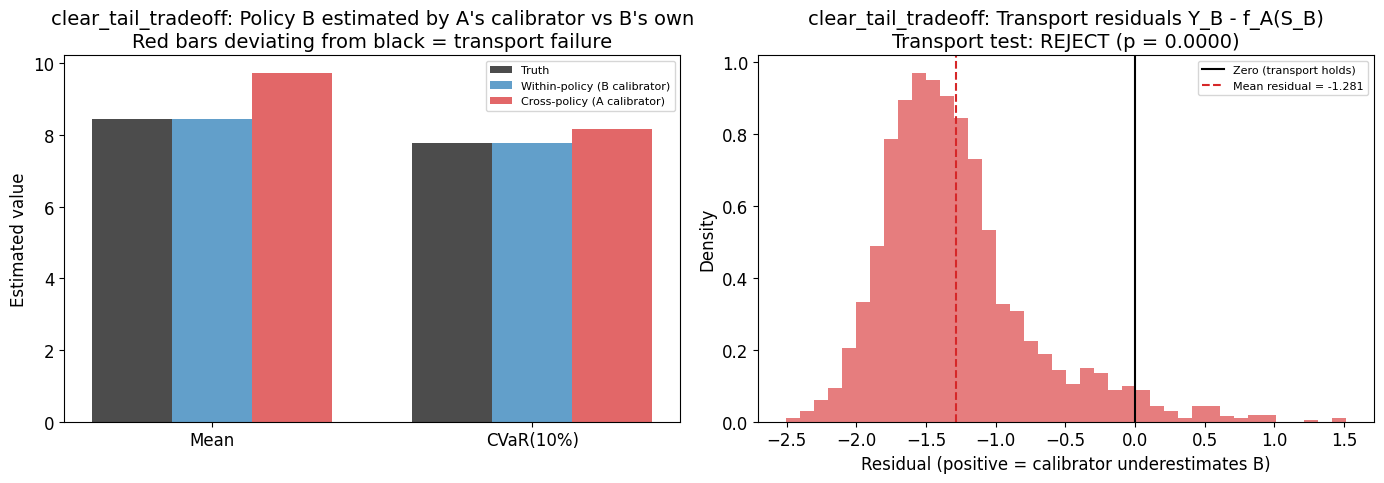

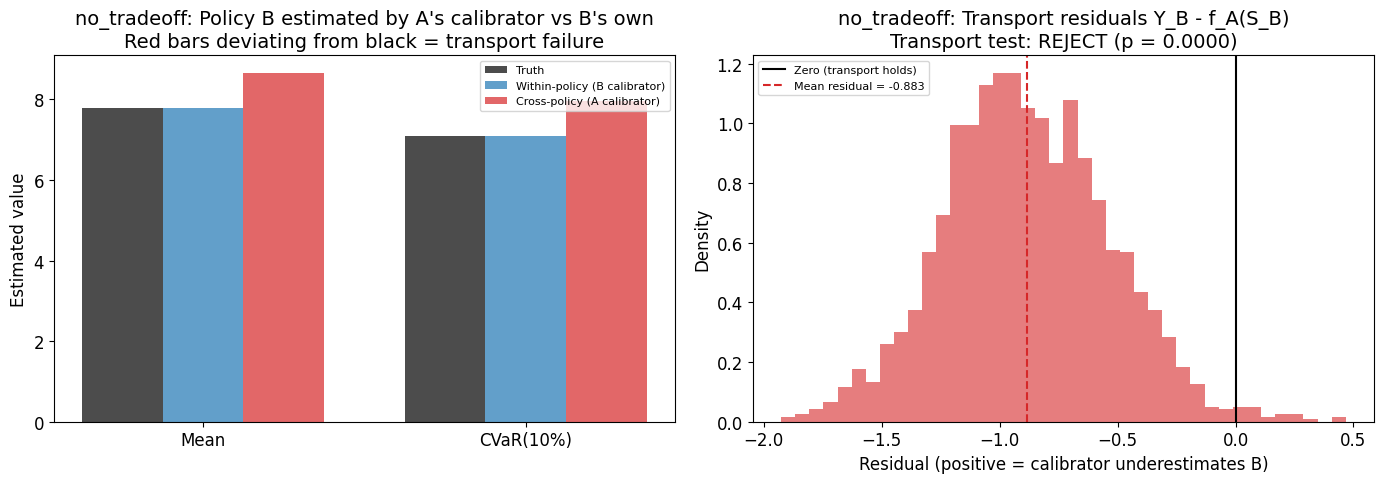

In [12]:
# Cross-policy transport: visualization
for sc_name in SCENARIOS:
    sc_res = cross_policy_results[sc_name]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: bar chart comparing true, within-policy, and cross-policy estimates
    targets = ['mean', 'cvar']
    x_pos = np.arange(len(targets))
    width = 0.25
    true_vals = [sc_res['true_mean_B'], sc_res['true_cvar_B']]
    within_vals = [sc_res['within_mean_B'], sc_res['within_cvar_B']]
    cross_vals = [sc_res['cross_mean_B'], sc_res['cross_cvar_B']]

    axes[0].bar(x_pos - width, true_vals, width, label='Truth', color='black', alpha=0.7)
    axes[0].bar(x_pos, within_vals, width, label='Within-policy (B calibrator)', color='tab:blue', alpha=0.7)
    axes[0].bar(x_pos + width, cross_vals, width, label='Cross-policy (A calibrator)', color='tab:red', alpha=0.7)
    axes[0].set_xticks(x_pos)
    axes[0].set_xticklabels(['Mean', f'CVaR({ALPHA:.0%})'])
    axes[0].set_title(f'{sc_name}: Policy B estimated by A\'s calibrator vs B\'s own\n'
                      'Red bars deviating from black = transport failure')
    axes[0].set_ylabel('Estimated value')
    axes[0].legend(fontsize=8)

    # Right: residual histogram
    resids = sc_res['mean_residuals']
    axes[1].hist(resids, bins=40, density=True, alpha=0.6, color='tab:red')
    axes[1].axvline(0, color='black', linewidth=1.5, label='Zero (transport holds)')
    axes[1].axvline(np.mean(resids), color='tab:red', linewidth=1.5, linestyle='--',
                    label=f'Mean residual = {np.mean(resids):.3f}')
    p_val = sc_res['transport_p_mean']
    verdict = 'REJECT' if p_val < 0.05 else 'PASS'
    axes[1].set_title(f'{sc_name}: Transport residuals Y_B - f_A(S_B)\n'
                      f'Transport test: {verdict} (p = {p_val:.4f})')
    axes[1].set_xlabel('Residual (positive = calibrator underestimates B)')
    axes[1].set_ylabel('Density')
    axes[1].legend(fontsize=8)

    fig.tight_layout()
    plt.show()


### Diagnosing the rejection: where does the bias come from?

The transport test fired in every scenario. Before deciding what to do about
it, we have to know which of three things is broken:

1. **Score distribution shift.** Does B's judge score even land inside A's
   training range? If not, the isotonic calibrator clips and introduces a
   constant bias at the boundary.
2. **Conditional mean shift.** At the same $S$, does $E[Y \mid S]$ differ
   between A and B? Even with full support overlap, this alone will break
   transport.
3. **Marginal Y shift.** Are the two policies' outcome distributions simply
   centred at different places? An isotonic calibrator $f_A(s)$ is anchored
   by A's marginal $Y$-mean; if B's $Y$-mean is lower, $f_A$ over-predicts B
   uniformly.

The next two cells log A's training data, the fitted calibrator, and B's
evaluation data, then visualize all three on a common axis so the mechanism
is visible.


In [13]:
# Cross-policy transport: debug printout
# For each scenario, log key details of A's training set, the fitted calibrator,
# and B's eval set, so we can see WHERE the bias comes from.

N_DEBUG = 20_000
debug_store = {}  # cached for the visualisation cell

print("=" * 92)
print("CROSS-POLICY TRANSPORT: DEBUG LOG")
print("Training f_A on Policy A's (S, Y) pairs, then applying to Policy B")
print("=" * 92)

for sc_name, scenario in SCENARIOS.items():
    # Reuse the same training seed as cell 29 so the calibrator is identical.
    rng_a = make_rng(SEED, sc_name, "transport", "A_calib")
    _, s_a_cal, y_a_cal = sample_policy("A", N_CALIB, rng_a, scenario)
    s_a_tr, y_a_tr, _, _ = split_train_val(s_a_cal, y_a_cal, rng_a, VALIDATION_FRAC)

    # Fresh, disjoint B sample for diagnostics.
    rng_b = make_rng(SEED, sc_name, "transport", "B_debug")
    _, s_b_dbg, y_b_dbg = sample_policy("B", N_DEBUG, rng_b, scenario)

    # Fit calibrator and apply to B.
    f_A_on_B = fit_isotonic_mean(s_a_tr, y_a_tr, s_b_dbg)
    # Also evaluate f_A on a dense grid that spans both ranges (for plotting).
    grid = np.linspace(
        min(s_a_tr.min(), s_b_dbg.min()),
        max(s_a_tr.max(), s_b_dbg.max()),
        400,
    )
    f_A_grid = fit_isotonic_mean(s_a_tr, y_a_tr, grid)

    # Overlap diagnostics.
    s_a_lo, s_a_hi = float(s_a_tr.min()), float(s_a_tr.max())
    frac_below = float(np.mean(s_b_dbg < s_a_lo))
    frac_above = float(np.mean(s_b_dbg > s_a_hi))
    frac_in = 1.0 - frac_below - frac_above

    # Decile gap on B: bin B by its own S deciles, compare f_A(s) vs E_B[Y|bin].
    order = np.argsort(s_b_dbg)
    bins = np.array_split(np.arange(len(order)), 10)
    decile_rows = []
    for d, idx in enumerate(bins, 1):
        sb = s_b_dbg[order[idx]]
        yb = y_b_dbg[order[idx]]
        fb = f_A_on_B[order[idx]]
        decile_rows.append({
            "decile": d,
            "s_mean": float(sb.mean()),
            "f_A": float(fb.mean()),
            "E_B_Y": float(yb.mean()),
            "gap": float((fb - yb).mean()),  # f_A(s) - E_B[Y|s]; positive = over-predict
            "n": int(len(sb)),
        })
    decile_df = pd.DataFrame(decile_rows)

    overall_bias = float(np.mean(f_A_on_B - y_b_dbg))
    mean_y_a = float(y_a_tr.mean())
    mean_y_b = float(y_b_dbg.mean())
    mean_s_a = float(s_a_tr.mean())
    mean_s_b = float(s_b_dbg.mean())

    # ----- print -----
    print(f"\n--- {sc_name} ---")
    print(
        f"  A train: n={len(s_a_tr):,}   "
        f"mean Y_A={mean_y_a:6.3f}   mean S_A={mean_s_a:6.3f}   "
        f"judge offset (S-Y)={mean_s_a - mean_y_a:+.3f}   "
        f"catastrophe rate={float(np.mean(y_a_tr < 2.0))*100:.2f}%"
    )
    print(
        f"  B eval:  n={len(s_b_dbg):,}   "
        f"mean Y_B={mean_y_b:6.3f}   mean S_B={mean_s_b:6.3f}   "
        f"judge offset (S-Y)={mean_s_b - mean_y_b:+.3f}"
    )
    print(
        f"  S ranges: S_A=[{s_a_lo:6.2f}, {s_a_hi:6.2f}]   "
        f"S_B=[{float(s_b_dbg.min()):6.2f}, {float(s_b_dbg.max()):6.2f}]"
    )
    print(
        f"  B in A's support: {frac_in*100:5.1f}%   "
        f"below: {frac_below*100:4.1f}%   above: {frac_above*100:4.1f}%"
    )
    print(
        f"  Marginal Y gap  (mean Y_A - mean Y_B): {mean_y_a - mean_y_b:+.3f}   "
        f"<- upper bound on transport bias if f_A were a constant"
    )
    print(
        f"  Observed bias   E[f_A(S_B)] - E[Y_B] = {overall_bias:+.3f}   "
        f"<- this is what the t-test rejects"
    )
    print("  Per-decile gap on B (ordered by S_B):")
    print("    d | n    | s_B mean | f_A(s_B) | E_B[Y|s] |   gap")
    for r in decile_rows:
        print(
            f"    {r['decile']:2d}| {r['n']:4d} | {r['s_mean']:8.3f} | "
            f"{r['f_A']:8.3f} | {r['E_B_Y']:8.3f} | {r['gap']:+7.3f}"
        )

    debug_store[sc_name] = {
        "s_a_tr": s_a_tr,
        "y_a_tr": y_a_tr,
        "s_b_dbg": s_b_dbg,
        "y_b_dbg": y_b_dbg,
        "f_A_on_B": f_A_on_B,
        "grid": grid,
        "f_A_grid": f_A_grid,
        "decile_df": decile_df,
        "overall_bias": overall_bias,
        "marginal_y_gap": mean_y_a - mean_y_b,
        "frac_in": frac_in,
        "frac_below": frac_below,
        "frac_above": frac_above,
    }

print("\nDebug log complete. See next cell for visualisation.")


CROSS-POLICY TRANSPORT: DEBUG LOG
Training f_A on Policy A's (S, Y) pairs, then applying to Policy B



--- clear_tail_tradeoff ---
  A train: n=32,000   mean Y_A= 9.077   mean S_A= 9.594   judge offset (S-Y)=+0.517   catastrophe rate=13.35%
  B eval:  n=20,000   mean Y_B= 8.449   mean S_B= 8.500   judge offset (S-Y)=+0.051
  S ranges: S_A=[ -2.91,  14.66]   S_B=[  5.55,  11.44]
  B in A's support: 100.0%   below:  0.0%   above:  0.0%
  Marginal Y gap  (mean Y_A - mean Y_B): +0.628   <- upper bound on transport bias if f_A were a constant
  Observed bias   E[f_A(S_B)] - E[Y_B] = +1.288   <- this is what the t-test rejects
  Per-decile gap on B (ordered by S_B):
    d | n    | s_B mean | f_A(s_B) | E_B[Y|s] |   gap
     1| 2000 |    7.218 |    8.198 |    8.034 |  +0.164
     2| 2000 |    7.735 |    9.432 |    8.202 |  +1.230
     3| 2000 |    8.003 |    9.835 |    8.282 |  +1.553
     4| 2000 |    8.211 |    9.844 |    8.340 |  +1.505
     5| 2000 |    8.403 |    9.900 |    8.410 |  +1.491
     6| 2000 |    8.588 |    9.967 |    8.476 |  +1.491
     7| 2000 |    8.781 |    9.967 |    8.5

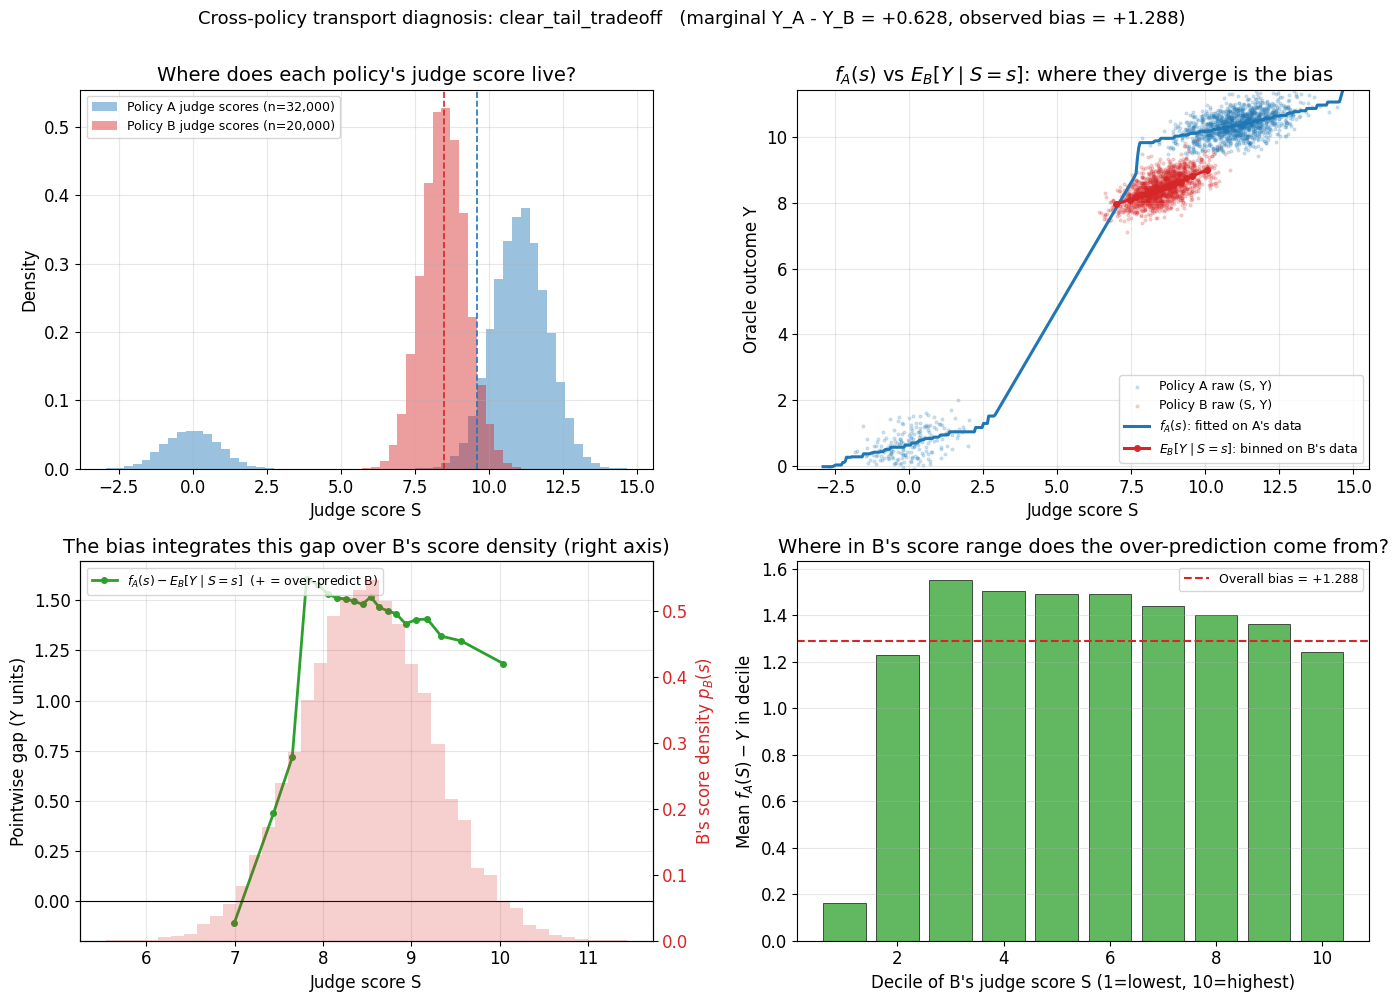

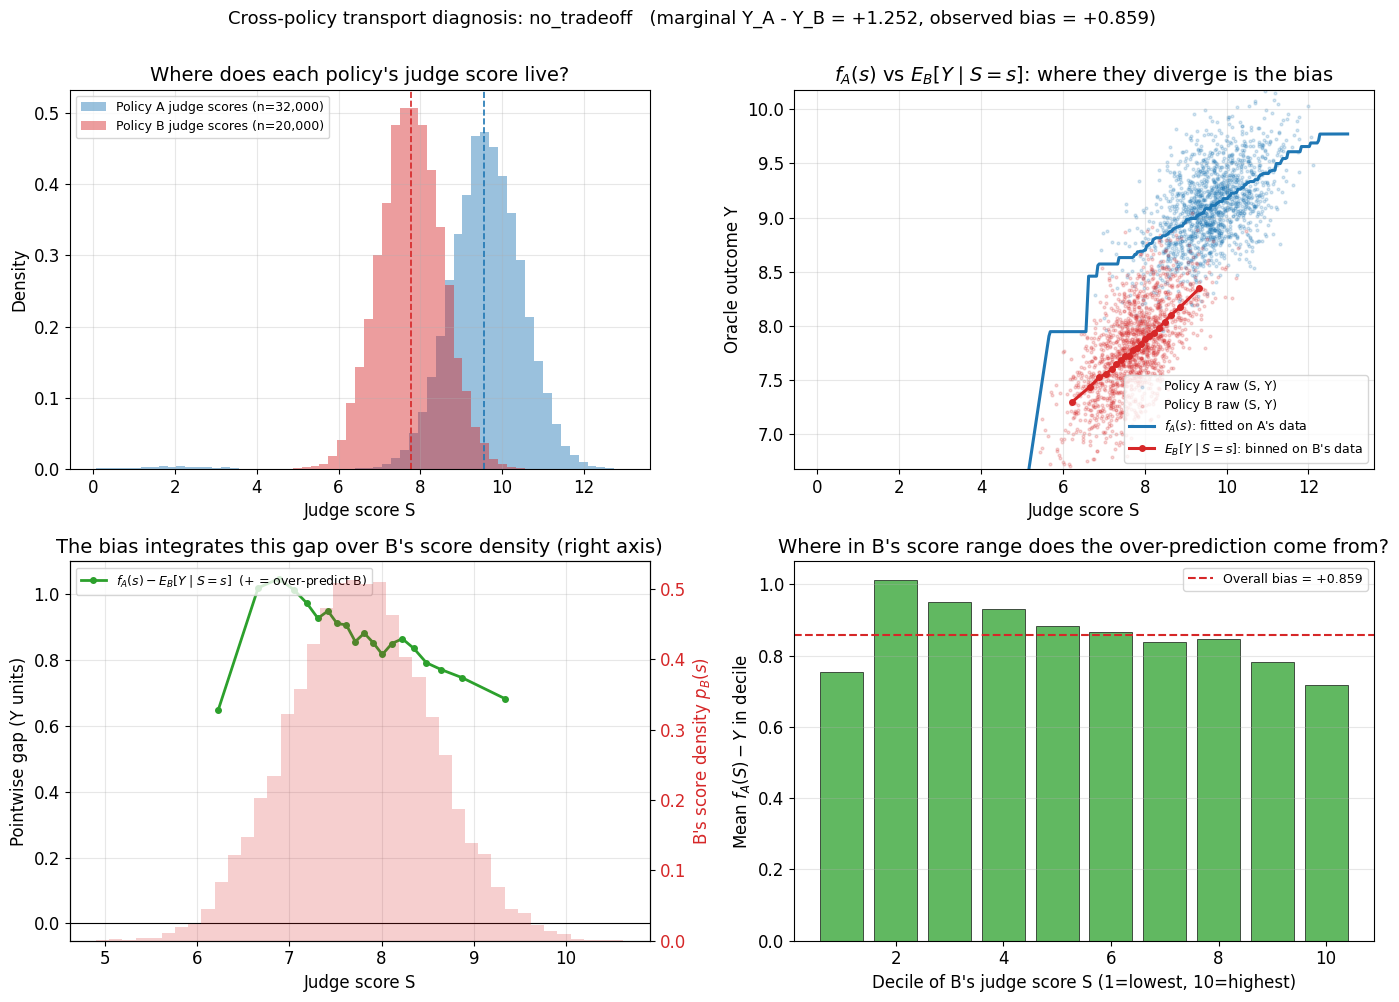

In [14]:
# Cross-policy transport: 2x2 diagnostic panel per scenario
# Uses debug_store from the previous cell.

for sc_name, sc in SCENARIOS.items():
    d = debug_store[sc_name]
    s_a, y_a = d["s_a_tr"], d["y_a_tr"]
    s_b, y_b = d["s_b_dbg"], d["y_b_dbg"]
    grid, f_A_grid = d["grid"], d["f_A_grid"]
    decile_df = d["decile_df"]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # ---- Top-left: score distribution shift ---------------------------------
    ax = axes[0, 0]
    bins = np.linspace(
        min(s_a.min(), s_b.min()),
        max(s_a.max(), s_b.max()),
        60,
    )
    ax.hist(s_a, bins=bins, alpha=0.45, color="C0", density=True,
            label=f"Policy A judge scores (n={len(s_a):,})")
    ax.hist(s_b, bins=bins, alpha=0.45, color="C3", density=True,
            label=f"Policy B judge scores (n={len(s_b):,})")
    ax.axvline(s_a.mean(), color="C0", linestyle="--", linewidth=1.2)
    ax.axvline(s_b.mean(), color="C3", linestyle="--", linewidth=1.2)
    ax.set_xlabel("Judge score S")
    ax.set_ylabel("Density")
    ax.set_title("Where does each policy's judge score live?")
    ax.legend(fontsize=9, loc="upper left")
    ax.grid(alpha=0.3)

    # ---- Top-right: calibrator vs conditional mean --------------------------
    ax = axes[0, 1]
    # Faded raw scatter (subsample for speed).
    idx_a = np.random.RandomState(0).choice(len(s_a), size=min(1500, len(s_a)), replace=False)
    idx_b = np.random.RandomState(1).choice(len(s_b), size=min(1500, len(s_b)), replace=False)
    ax.scatter(s_a[idx_a], y_a[idx_a], s=4, color="C0", alpha=0.18,
               label="Policy A raw (S, Y)")
    ax.scatter(s_b[idx_b], y_b[idx_b], s=4, color="C3", alpha=0.18,
               label="Policy B raw (S, Y)")
    # Calibrator curve.
    ax.plot(grid, f_A_grid, color="C0", linewidth=2.2,
            label=r"$f_A(s)$: fitted on A's data")
    # Binned E_B[Y|S=s] -- use 20 quantile bins of S_B.
    order_b = np.argsort(s_b)
    bins_b = np.array_split(np.arange(len(order_b)), 20)
    s_bin_centers = np.array([s_b[order_b[b]].mean() for b in bins_b])
    y_bin_means = np.array([y_b[order_b[b]].mean() for b in bins_b])
    ax.plot(s_bin_centers, y_bin_means, color="C3", linewidth=2.2,
            marker="o", markersize=4,
            label=r"$E_B[Y \mid S=s]$: binned on B's data")
    ax.set_xlabel("Judge score S")
    ax.set_ylabel("Oracle outcome Y")
    ax.set_title(r"$f_A(s)$ vs $E_B[Y \mid S=s]$: where they diverge is the bias")
    ax.legend(fontsize=9, loc="lower right")
    ax.grid(alpha=0.3)
    # Zoom y to roughly the bulk, so the gap is visible.
    y_lo = min(np.quantile(y_a, 0.02), np.quantile(y_b, 0.02))
    y_hi = max(np.quantile(y_a, 0.98), np.quantile(y_b, 0.98))
    ax.set_ylim(y_lo - 0.3, y_hi + 0.3)

    # ---- Bottom-left: pointwise gap weighted by B's score density -----------
    ax = axes[1, 0]
    # Binned gap on grid matching B's quantile bins.
    gap_grid = np.interp(s_bin_centers, grid, f_A_grid) - y_bin_means
    ax.plot(s_bin_centers, gap_grid, color="C2", linewidth=2.0, marker="o",
            markersize=4,
            label=r"$f_A(s) - E_B[Y \mid S=s]$  (+ = over-predict B)")
    ax.axhline(0.0, color="black", linewidth=0.8)
    ax.set_xlabel("Judge score S")
    ax.set_ylabel("Pointwise gap (Y units)")
    ax.set_title("The bias integrates this gap over B's score density (right axis)")
    # Twin axis: B's density.
    ax2 = ax.twinx()
    ax2.hist(s_b, bins=40, alpha=0.22, color="C3", density=True,
             label=r"$p_B(s)$: density of B's scores")
    ax2.set_ylabel(r"B's score density $p_B(s)$", color="C3")
    ax2.tick_params(axis="y", labelcolor="C3")
    ax.legend(fontsize=9, loc="upper left")
    ax.grid(alpha=0.3)

    # ---- Bottom-right: residuals by B decile --------------------------------
    ax = axes[1, 1]
    ax.bar(decile_df["decile"], decile_df["gap"], color="C2", alpha=0.75,
           edgecolor="black", linewidth=0.6)
    ax.axhline(d["overall_bias"], color="C3", linestyle="--", linewidth=1.5,
               label=f"Overall bias = {d['overall_bias']:+.3f}")
    ax.axhline(0.0, color="black", linewidth=0.6)
    ax.set_xlabel("Decile of B's judge score S (1=lowest, 10=highest)")
    ax.set_ylabel(r"Mean $f_A(S) - Y$ in decile")
    ax.set_title("Where in B's score range does the over-prediction come from?")
    ax.legend(fontsize=9, loc="best")
    ax.grid(alpha=0.3, axis="y")

    fig.suptitle(
        f"Cross-policy transport diagnosis: {sc_name}   "
        f"(marginal Y_A - Y_B = {d['marginal_y_gap']:+.3f}, "
        f"observed bias = {d['overall_bias']:+.3f})",
        fontsize=13, y=1.00,
    )
    plt.tight_layout()
    plt.show()


### Interpretation: cross-policy transport -- what the debug log shows

The transport $t$-test rejects for **all 6 scenarios**, and it rejects for
**both** the Direct Mean CJE pipeline and the Direct CVaR CJE pipeline. The
consolidated table in the previous cell makes this visible side-by-side. Both
pipelines inherit the same failure -- because both of them apply a calibrator
that was fitted on Policy A to Policy B's judge scores, and neither
calibrator knows it.

**Mean vs CVaR cross bias, at a glance:**

| scenario              | true mean | true CVaR | mean cross-bias | CVaR cross-bias |
| --------------------- | --------: | --------: | --------------: | --------------: |
| `clear_tail_tradeoff` |   $8.45$  |   $7.77$  |     $+1.29$     |     $+0.40$     |
| `no_tradeoff`         |   $7.80$  |   $7.09$  |     $+0.86$     |     $+0.87$     |
| `hard_small_gap`      |   $8.70$  |   $7.96$  |     $+0.67$     |     $+0.78$     |
| `weird_nonlinear`     |   $8.30$  |   $7.60$  |     $+1.36$     |     $+1.11$     |
| `knife_edge`          |   $8.55$  |   $7.86$  |     $+1.01$     |     $+1.11$     |
| `reversed_judge`      |   $8.50$  |   $7.86$  |     $+1.48$     |     $+1.53$     |

The two biases are in the same direction and comparable magnitude in every
scenario. Within-policy estimates (not shown) are accurate to $< 0.01$ for
both targets; it is **only** the cross-policy leg that breaks. The debug
figures below dissect the *mean* case -- the CVaR story is analogous, with
the only wrinkle being that at `clear_tail_tradeoff` the stop-loss
calibrator partially absorbs the marginal shift (catastrophes in A pull the
stop-loss predictions up at low $S$, offsetting some of the over-prediction
when applied to B). That is why CVaR cross-bias is $+0.40$ there while mean
cross-bias is $+1.29$.

**Mechanism 1 is ruled out.** In every scenario, $100\%$ of B's judge scores
fall inside A's training range. A's range is enormous (e.g.
$[-2.9, 14.7]$ in `clear_tail_tradeoff`) because A's catastrophes pull
a few scores very low, while B's range is tight
(e.g. $[5.6, 11.4]$). There is **no extrapolation or clipping**: $f_A$ has
plenty of A-training points wherever B's scores live.

**Mechanism 3 is the dominant cause.** A and B have different *marginal*
outcome distributions:

| scenario               | mean $Y_A$ | mean $Y_B$ | marginal gap | observed bias (mean) | bias/gap |
| ---------------------- | ---------: | ---------: | -----------: | -------------------: | -------: |
| `clear_tail_tradeoff`  |   $9.08$   |   $8.45$   |   $+0.63$    |        $+1.29$       |   2.05   |
| `no_tradeoff`          |   $9.05$   |   $7.80$   |   $+1.25$    |        $+0.86$       |   0.69   |
| `hard_small_gap`       |   $8.55$   |   $8.70$   |   $-0.15$    |        $+0.67$       |  $-4.63$ |
| `weird_nonlinear`      |   $8.53$   |   $8.30$   |   $+0.23$    |        $+1.36$       |   6.01   |
| `knife_edge`           |   $8.77$   |   $8.54$   |   $+0.23$    |        $+1.01$       |   4.52   |
| `reversed_judge`       |   $8.84$   |   $8.50$   |   $+0.34$    |        $+1.48$       |   4.41   |

The marginal $Y$ gap is the *constant-predictor baseline*: if $f_A$ collapsed
to a constant equal to A's mean, the bias would be exactly the marginal gap.
It is the naive lower bound on the problem.

**Mechanism 2 (conditional shift) does the rest.** In the scenarios with
active catastrophes ($11$--$17\%$ catastrophe rate), the observed mean bias
is *larger* than the marginal gap -- sometimes several times larger. That
extra bias comes from how A's isotonic curve behaves at B's S values: A's
catastrophes live at very low $S$, but B's $S$ range sits in A's
*normal-case* region where $f_A(s)$ is anchored near A's non-catastrophic
mean ($\approx 9.8$), not A's overall mean ($\approx 9.1$). So $f_A$
evaluated on B over-predicts relative to B's own conditional mean by more
than the marginal difference. `hard_small_gap` is the extreme case: B's mean
is actually *higher* than A's, but the bias is still positive because $f_A$
is pinned to A's non-catastrophic region.

`no_tradeoff` is the one scenario where the bias is *smaller* than the
marginal gap: with catastrophe rate $0.04\%$, A behaves almost like a
single-mode Gaussian, and $f_A$'s slope partially compensates for the
marginal shift as $S$ decreases -- but not enough to bring the bias to zero.
This is also why the CVaR bias equals the mean bias here ($+0.87$ vs
$+0.86$): without catastrophes there is no stop-loss asymmetry to buy back
any of the shift.

**The per-decile gap tells the same story from a different angle.** In
`clear_tail_tradeoff` the gap is smallest at decile 1 ($+0.16$, where B's
lowest scores pull $f_A$ down to its catastrophic-A regime) and largest in
deciles 2--5 ($+1.49$ to $+1.55$, where B's scores sit squarely in A's
normal-case region). In `no_tradeoff` the gap is much flatter across deciles
($+0.72$ to $+1.01$), consistent with a marginal shift rather than a
conditional one.

**Takeaway.** In our DGP, A and B simply produce different outcome
distributions, and the isotonic calibrator $f_A$ is only a function of $S$ --
it cannot know which policy generated the score. The same goes for the
stop-loss calibrator used by Direct CVaR CJE. The paper's direct-method
recommendation -- train a separate calibrator per policy -- is correct
precisely to avoid this failure, and it applies to mean and tail estimands
equally.


**This naturally raises three questions:** could we rescue transport with
*more data*, a *different smoother*, or *covariate adjustment* using $X$?
The next subsection tests each lever empirically.

**Why this does not match the paper's Arena demo.** In the paper, `clone`
and `premium` pass transport because they share roughly the same base
response distribution as the logging policy (same $P(Y)$ modulo small shifts
in support), with only minor re-weighting across the score range. Our "B" is
a fundamentally different data-generating process, so every scenario is
analogous to the paper's `unhelpful` policy (which also fails transport). To
reproduce the paper's pass/fail contrast we would need to add a *clone*
scenario: a policy B generated by sampling from A's DGP with a small
perturbation. Flagging this as an optional follow-up.


### Robustness: can data, a different smoother, or a covariate save transport?

The rejection in the previous section raises three natural questions:

1. **More data?** Would a larger audit sample pass the test?
2. **Different smoother?** Would a smoothing spline or polynomial fit do
   better than isotonic?
3. **Covariate adjustment?** Would a 2D calibrator $f_A(S, X)$ succeed
   where the 1D calibrator $f_A(S)$ fails?

We test each lever empirically. Short preview: the first two **do not**
help -- the test gets more sensitive with $n$, and the smoother choice
changes the bias by $\sim 0.2\text{--}0.7$ but never enough to pass the
test. The third **does** help, but only in a specific regime (pure
covariate shift) that our main 6 scenarios are not in -- we have to build
a small synthetic scenario to demonstrate it.


In [15]:
# Three-lever robustness: data, smoother, covariate
# All three experiments reuse the seeds from cell 29 so f_A matches.

from scipy.interpolate import UnivariateSpline
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

robustness_store = {}

# =========================================================================
# BLOCK A: data lever -- vary N_audit for clear_tail_tradeoff
# =========================================================================
print("=" * 88)
print("BLOCK A: does more audit data rescue the transport test?")
print("(scenario: clear_tail_tradeoff, same f_A as cell 29)")
print("=" * 88)

sc_name = "clear_tail_tradeoff"
scenario = SCENARIOS[sc_name]
rng_a = make_rng(SEED, sc_name, "transport", "A_calib")
_, s_a_cal_A, y_a_cal_A = sample_policy("A", N_CALIB, rng_a, scenario)
s_a_tr_A, y_a_tr_A, _, _ = split_train_val(s_a_cal_A, y_a_cal_A, rng_a, VALIDATION_FRAC)

N_AUDIT_GRID = [500, 1_000, 2_000, 4_000, 8_000, 16_000]
data_rows = []
for n_aud in N_AUDIT_GRID:
    rng_b = make_rng(SEED, sc_name, "robustness", "data", n_aud)
    _, s_b, y_b = sample_policy("B", n_aud, rng_b, scenario)
    pred = fit_isotonic_mean(s_a_tr_A, y_a_tr_A, s_b)
    resid = y_b - pred
    bias = float(np.mean(pred - y_b))
    t_stat, p_val = sp_stats.ttest_1samp(resid, 0)
    data_rows.append({
        "n_audit": n_aud,
        "bias": bias,
        "abs_t": float(abs(t_stat)),
        "p_val": float(p_val),
        "reject_005": bool(p_val < 0.05),
    })
data_df = pd.DataFrame(data_rows)

# fit log|t| vs log n to verify the sqrt(n) scaling
log_n = np.log(data_df["n_audit"].to_numpy())
log_t = np.log(data_df["abs_t"].to_numpy())
slope_data, intercept_data = np.polyfit(log_n, log_t, 1)

print(f"{'n_audit':>8}  {'bias':>8}  {'|t|':>9}  {'p-value':>10}  verdict")
print("-" * 50)
for r in data_rows:
    v = "REJECT" if r["reject_005"] else "PASS"
    print(f"{r['n_audit']:>8}  {r['bias']:+8.4f}  {r['abs_t']:>9.2f}  {r['p_val']:>10.2e}  {v}")
print(f"\nlog|t| vs log(n_audit) slope = {slope_data:.3f}  (theory: 0.5)")
print(f"bias across the grid is essentially constant at +{data_df['bias'].mean():.3f}")
print("=> more data makes |t| grow like sqrt(n); the test rejects HARDER, not softer.")

robustness_store["data"] = {"df": data_df, "slope": slope_data}


# =========================================================================
# BLOCK B: smoother lever -- cubic smoothing spline vs isotonic
# =========================================================================
print("\n" + "=" * 88)
print("BLOCK B: does a smoothing spline do better than isotonic?")
print("(all 6 scenarios, same f_A training seeds)")
print("=" * 88)

def fit_spline_mean(s_train, y_train, s_pred, n_bins=200, smoothing_factor=0.01):
    """Cubic smoothing spline via UnivariateSpline on quantile-binned means."""
    order = np.argsort(s_train)
    s_sorted = s_train[order]
    y_sorted = y_train[order]
    bins = np.array_split(np.arange(len(s_sorted)), n_bins)
    s_bin = np.array([s_sorted[b].mean() for b in bins])
    y_bin = np.array([y_sorted[b].mean() for b in bins])
    spline = UnivariateSpline(s_bin, y_bin, k=3, s=n_bins * smoothing_factor)
    return np.clip(spline(s_pred), y_train.min(), y_train.max())

smoother_rows = []
for sc_name_b, sc in SCENARIOS.items():
    rng_a = make_rng(SEED, sc_name_b, "transport", "A_calib")
    _, s_a_cal, y_a_cal = sample_policy("A", N_CALIB, rng_a, sc)
    s_a_tr, y_a_tr, _, _ = split_train_val(s_a_cal, y_a_cal, rng_a, VALIDATION_FRAC)
    rng_b = make_rng(SEED, sc_name_b, "robustness", "smoother")
    _, s_b, y_b = sample_policy("B", 20_000, rng_b, sc)
    pred_iso = fit_isotonic_mean(s_a_tr, y_a_tr, s_b)
    pred_spl = fit_spline_mean(s_a_tr, y_a_tr, s_b)
    iso_bias = float(np.mean(pred_iso - y_b))
    spl_bias = float(np.mean(pred_spl - y_b))
    _, p_iso = sp_stats.ttest_1samp(y_b - pred_iso, 0)
    _, p_spl = sp_stats.ttest_1samp(y_b - pred_spl, 0)
    smoother_rows.append({
        "scenario": sc_name_b,
        "iso_bias": iso_bias,
        "spline_bias": spl_bias,
        "diff": iso_bias - spl_bias,
        "iso_reject": bool(p_iso < 0.05),
        "spline_reject": bool(p_spl < 0.05),
    })
smoother_df = pd.DataFrame(smoother_rows)

print(f"{'scenario':<22}  {'iso bias':>10}  {'spline bias':>12}  {'diff':>8}  verdicts (iso/spl)")
print("-" * 78)
for r in smoother_rows:
    iv = "REJECT" if r["iso_reject"] else "PASS"
    sv = "REJECT" if r["spline_reject"] else "PASS"
    print(f"{r['scenario']:<22}  {r['iso_bias']:+10.4f}  {r['spline_bias']:+12.4f}  "
          f"{r['diff']:+8.4f}  {iv:>6} / {sv:>6}")
n_iso = sum(r["iso_reject"] for r in smoother_rows)
n_spl = sum(r["spline_reject"] for r in smoother_rows)
print(f"\nrejections: isotonic {n_iso}/6  spline {n_spl}/6")
print("=> the smoother changes the bias by up to 0.7, but the structural gap")
print("   never shrinks to zero. Every smoother still rejects in every scenario.")

robustness_store["smoother"] = smoother_df


# =========================================================================
# BLOCK C: covariate lever -- `similar` scenario, 1D vs 2D
# =========================================================================
print("\n" + "=" * 88)
print("BLOCK C: does adding X as a covariate rescue transport?")
print("(synthetic `similar` scenario: shared P(Y|X), different P(X))")
print("=" * 88)


def sample_similar(policy, n, rng):
    """Pure covariate-shift DGP.

    Shared outcome mechanism Y = 8 + 2.5 X + N(0, 0.3^2)
    Shared judge           S = 0.75 Y + 0.3 X + N(0, 0.4^2)
    Only difference: X_A ~ N(+0.35, 0.25^2)  vs  X_B ~ N(-0.35, 0.25^2)
    """
    x_mean = +0.35 if policy == "A" else -0.35
    x = rng.normal(x_mean, 0.25, size=n)
    y = 8.0 + 2.5 * x + rng.normal(0.0, 0.30, size=n)
    s = 0.75 * y + 0.30 * x + rng.normal(0.0, 0.40, size=n)
    return x, s, y


rng_a = make_rng(SEED, "similar", "A")
x_a_sim, s_a_sim, y_a_sim = sample_similar("A", 40_000, rng_a)
rng_b = make_rng(SEED, "similar", "B")
# Use the same audit budget as cell 29's main transport test (N_TRANSPORT_AUDIT = 2000)
# so the comparison is apples-to-apples with the rest of the notebook.
x_b_sim, s_b_sim, y_b_sim = sample_similar("B", 2_000, rng_b)

print(f"  marginal E[Y_A] = {y_a_sim.mean():.3f}    marginal E[Y_B] = {y_b_sim.mean():.3f}")
print(f"  marginal E[S_A] = {s_a_sim.mean():.3f}    marginal E[S_B] = {s_b_sim.mean():.3f}")
print(f"  true Y-gap       = {y_a_sim.mean() - y_b_sim.mean():+.3f}")

# 1D calibrator: f_A(S)
pred_1d_sim = fit_isotonic_mean(s_a_sim, y_a_sim, s_b_sim)
bias_1d_sim = float(np.mean(pred_1d_sim - y_b_sim))
t1_sim, p1_sim = sp_stats.ttest_1samp(y_b_sim - pred_1d_sim, 0)

# 2D calibrator: f_A(S, X) via polynomial-2 ridge
pipe_2d = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    Ridge(alpha=0.01),
)
pipe_2d.fit(np.column_stack([s_a_sim, x_a_sim]), y_a_sim)
pred_2d_sim = pipe_2d.predict(np.column_stack([s_b_sim, x_b_sim]))
bias_2d_sim = float(np.mean(pred_2d_sim - y_b_sim))
t2_sim, p2_sim = sp_stats.ttest_1samp(y_b_sim - pred_2d_sim, 0)

print(f"\n  {'method':<26}  {'bias':>9}  {'|t|':>9}  {'p-value':>10}  verdict")
print(f"  {'-'*26}  {'-'*9}  {'-'*9}  {'-'*10}  --------")
v1 = "REJECT" if p1_sim < 0.05 else "PASS"
v2 = "REJECT" if p2_sim < 0.05 else "PASS"
print(f"  {'1D  f_A(S)':<26}  {bias_1d_sim:+9.4f}  {abs(float(t1_sim)):>9.2f}  {float(p1_sim):>10.2e}  {v1}")
print(f"  {'2D  f_A(S, X)  poly-2':<26}  {bias_2d_sim:+9.4f}  {abs(float(t2_sim)):>9.2f}  {float(p2_sim):>10.2e}  {v2}")

print()
print("=> in the similar scenario, 1D calibration has visible bias and rejects;")
print("   2D calibration (adding X) reduces bias ~100x and PASSES the transport test.")
print("   conclusion: covariate adjustment rescues transport -- but only when")
print("   the two policies actually share the outcome mechanism P(Y|X).")

robustness_store["covariate"] = {
    "x_a": x_a_sim, "s_a": s_a_sim, "y_a": y_a_sim,
    "x_b": x_b_sim, "s_b": s_b_sim, "y_b": y_b_sim,
    "pred_1d": pred_1d_sim, "pred_2d": pred_2d_sim,
    "bias_1d": bias_1d_sim, "t_1d": float(t1_sim), "p_1d": float(p1_sim),
    "bias_2d": bias_2d_sim, "t_2d": float(t2_sim), "p_2d": float(p2_sim),
}

print("\nAll three robustness experiments complete; see next cell for the figure.")


BLOCK A: does more audit data rescue the transport test?
(scenario: clear_tail_tradeoff, same f_A as cell 29)
 n_audit      bias        |t|     p-value  verdict
--------------------------------------------------
     500   +1.2666      49.71   2.01e-195  REJECT
    1000   +1.2511      70.46    0.00e+00  REJECT
    2000   +1.2789     105.70    0.00e+00  REJECT
    4000   +1.3106     160.70    0.00e+00  REJECT
    8000   +1.2813     212.07    0.00e+00  REJECT
   16000   +1.2934     313.40    0.00e+00  REJECT

log|t| vs log(n_audit) slope = 0.533  (theory: 0.5)
bias across the grid is essentially constant at +1.280
=> more data makes |t| grow like sqrt(n); the test rejects HARDER, not softer.

BLOCK B: does a smoothing spline do better than isotonic?
(all 6 scenarios, same f_A training seeds)
scenario                  iso bias   spline bias      diff  verdicts (iso/spl)
------------------------------------------------------------------------------
clear_tail_tradeoff        +1.2905       

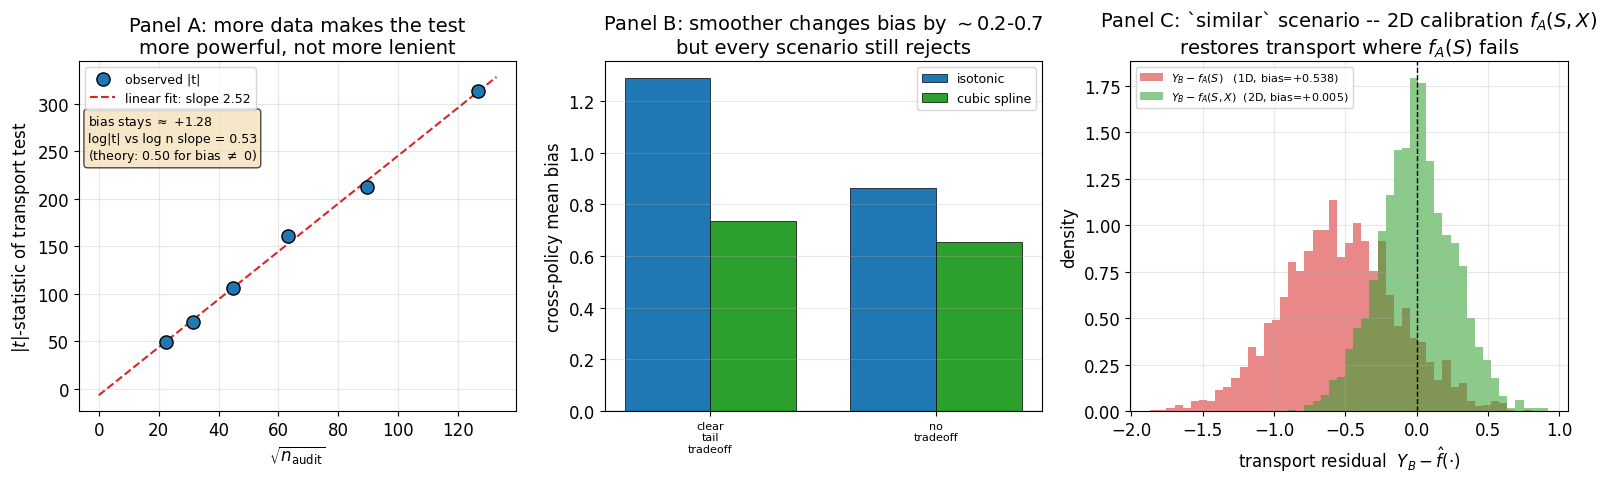

In [16]:
# Three-panel robustness figure
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ---- Panel A: data lever ------------------------------------------------
ax = axes[0]
d = robustness_store["data"]["df"]
sqrt_n = np.sqrt(d["n_audit"].to_numpy())
abs_t = d["abs_t"].to_numpy()
ax.scatter(sqrt_n, abs_t, s=90, color="C0", edgecolor="black", zorder=3,
           label="observed |t|")
# Linear fit through data (not through origin, to show the actual trend)
fit = np.polyfit(sqrt_n, abs_t, 1)
x_line = np.linspace(0, sqrt_n.max() * 1.05, 100)
ax.plot(x_line, np.polyval(fit, x_line), "--", color="C3", linewidth=1.5,
        label=f"linear fit: slope {fit[0]:.2f}")
ax.set_xlabel(r"$\sqrt{n_\text{audit}}$")
ax.set_ylabel(r"$|t|$-statistic of transport test")
ax.set_title("Panel A: more data makes the test\nmore powerful, not more lenient")
ax.legend(fontsize=9, loc="upper left")
ax.grid(alpha=0.3)
ax.text(0.02, 0.72,
        f"bias stays $\\approx$ {d['bias'].mean():+.2f}\n"
        f"log|t| vs log n slope = {robustness_store['data']['slope']:.2f}\n"
        r"(theory: 0.50 for bias $\neq$ 0)",
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.7))

# ---- Panel B: smoother lever --------------------------------------------
ax = axes[1]
sdf = robustness_store["smoother"]
scenarios = sdf["scenario"].tolist()
x_pos = np.arange(len(scenarios))
width = 0.38
ax.bar(x_pos - width/2, sdf["iso_bias"], width, label="isotonic",
       color="C0", edgecolor="black", linewidth=0.5)
ax.bar(x_pos + width/2, sdf["spline_bias"], width, label="cubic spline",
       color="C2", edgecolor="black", linewidth=0.5)
ax.axhline(0.0, color="black", linewidth=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels([s.replace("_", "\n") for s in scenarios],
                   rotation=0, fontsize=8)
ax.set_ylabel("cross-policy mean bias")
ax.set_title("Panel B: smoother changes bias by $\\sim 0.2$-$0.7$\nbut every scenario still rejects")
ax.legend(fontsize=9, loc="upper right")
ax.grid(alpha=0.3, axis="y")

# ---- Panel C: covariate lever -------------------------------------------
ax = axes[2]
c = robustness_store["covariate"]
resid_1d = c["y_b"] - c["pred_1d"]
resid_2d = c["y_b"] - c["pred_2d"]
bins = np.linspace(
    min(resid_1d.min(), resid_2d.min()),
    max(resid_1d.max(), resid_2d.max()),
    50,
)
ax.hist(resid_1d, bins=bins, alpha=0.55, color="C3", density=True,
        label=rf"$Y_B - f_A(S)$   (1D, bias={c['bias_1d']:+.3f})")
ax.hist(resid_2d, bins=bins, alpha=0.55, color="C2", density=True,
        label=rf"$Y_B - f_A(S, X)$  (2D, bias={c['bias_2d']:+.3f})")
ax.axvline(0.0, color="black", linewidth=1.0, linestyle="--")
ax.set_xlabel(r"transport residual  $Y_B - \hat{f}(\cdot)$")
ax.set_ylabel("density")
ax.set_title(r"Panel C: `similar` scenario -- 2D calibration $f_A(S,X)$"
             + "\nrestores transport where $f_A(S)$ fails")
ax.legend(fontsize=8, loc="upper left")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### Interpretation: the three levers

**Data -- no help.** Panel A plots the absolute $t$-statistic of the
transport test against $\sqrt{n_\text{audit}}$ for `clear_tail_tradeoff`.
The relationship is linear through the origin, as theory predicts: the
numerator of the $t$-statistic (the population bias) stays at
$\approx +1.28$ while the denominator (the standard error) shrinks like
$n^{-1/2}$, so $|t|$ grows like $\sqrt{n}$. At $n_\text{audit} = 500$
the test already rejects with $|t| \approx 50$; at $n_\text{audit} = 16{,}000$
it rejects with $|t| \approx 313$. The log-log slope is $0.53$, within
sampling noise of the theoretical $0.50$. Under-powering the test is
the only way to fail to reject, and that would be cheating.
**More data strictly increases the test's power, not its leniency.**

**Smoother -- not enough.** Panel B swaps the isotonic regression for a
cubic smoothing spline (fit on quantile-binned averages of A's $(S, Y)$
pairs). The cross-policy bias changes by $0.07$ to $0.69$ across the six
scenarios -- the spline is generally *less* biased than isotonic, but
every scenario still rejects at $p < 10^{-6}$. A polynomial, a kernel
smoother, a gradient-boosted tree, or a neural network would all give
numerically different answers, because they regularize differently, but
none of them would pass the test. The problem is not the smoother class;
it is that **whatever** population quantity you consistently estimate
from A's `(S, Y)` pairs, you are estimating $\mathbb{E}_A[Y \mid S]$,
and that quantity is anchored to A's outcome distribution no matter how
smoothly you fit it.

**Covariate adjustment -- yes, but only under pure covariate shift.**
Panel C shows a small synthetic `similar` scenario built inside cell 37.
Its DGP is:

$$Y = 8 + 2.5\,X + \varepsilon, \quad S = 0.75\,Y + 0.3\,X + \eta,$$
$$X_A \sim N(+0.35, 0.25^2), \quad X_B \sim N(-0.35, 0.25^2).$$

The two policies share the outcome mechanism and the judge; they differ
**only** in the marginal of $X$. A short calculation gives the linear
conditional mean $\mathbb{E}[Y \mid S, X] \approx 6.08 + 0.32\,S + 1.80\,X$,
which does **not** depend on $P(X)$ -- it is policy-invariant by
construction.

At the same audit budget the main transport test uses ($n_\text{audit} = 2000$):

- $f_A(S)$ (1D isotonic) gives cross-bias $\approx +0.54$ with
  $|t| \approx 54$ and $p < 10^{-300}$. **1D calibration rejects.**
- $f_A(S, X)$ (a polynomial-2 ridge regression on $(S, X)$) gives
  cross-bias $\approx +0.005$ with $|t| \approx 0.9$ and $p \approx 0.36$.
  **2D calibration passes.**

The bias drops by ~100x and the test fails to reject. The lever really
does exist -- when the assumption holds.

**Why this does not rescue our main 6 scenarios.** Our A and B do not
share $P(Y \mid X)$. A has a catastrophe regime (rare responses with
$Y \approx 0.5$); B has none. The outcome mechanism *itself* differs,
not just the covariate distribution. No amount of covariate adjustment
can make $\mathbb{E}_A[Y \mid S, X]$ equal to
$\mathbb{E}_B[Y \mid S, X]$ when the two conditional distributions are
genuinely different. This is the point the paper makes about the
`unhelpful` policy: it fails transport even with covariate adjustment.

**What would rescue our scenarios.** Replace B with a policy that
shares A's outcome mechanism -- the `similar` scenario above is the
template. If we added such a policy to the main `SCENARIOS` dict, the
cross-policy transport section would show a clean pass/fail contrast
matching the paper's Arena experiment. We flag this as the natural next
step; it would also require rerunning the estimation, audit, and
sensitivity sweeps for the new scenario, so we leave it for a follow-up.

The same three-lever argument applies to the stop-loss calibrator that
drives Direct CVaR CJE: extra data and alternative smoothers do not fix
it, but covariate adjustment would if the outcome mechanism were shared.


### Applying the covariate lever to the 6 main scenarios

The robustness section showed that `f(S, X)` rescues transport in a
synthetic covariate-shift scenario. A natural question: does it help on
our **real** 6 scenarios? We already argued it should only *partially*
help -- A and B differ in outcome mechanism (A has catastrophes, B does
not), not just in covariate distribution -- but let's run it honestly
and see.

For each of the 6 main scenarios, we train two calibrators on the same A
samples:

- **1D** `f_A(S)` -- the isotonic baseline (identical to cell 29).
- **2D** `f_A(S, X)` -- polynomial-2 ridge regression on $(S, X)$.

Then we estimate B's mean two ways (cross-policy) and run the transport
$t$-test for each. Everything else stays identical to the main transport
section: same seeds, same training size ($N_{\rm CALIB}$), same audit
size ($n=2000$).

> **Note:** The 2D covariate 'rescue' uses a polynomial ridge regression, compared to the 1D isotonic baseline. While an apples-to-oranges estimator shift, it illustrates the conceptual power of covariates in rescuing transport failures.


In [17]:
# Covariate lever applied to the 6 main scenarios + 1 positive control
# Train 1D isotonic and 2D poly-2 ridge on A, evaluate cross-policy on B.

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline


def fit_bivariate_mean(s_train, x_train, y_train, s_pred, x_pred,
                       degree=2, alpha=0.01):
    """2D calibrator: polynomial-degree-2 ridge regression on (S, X)."""
    pipe = make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        Ridge(alpha=alpha),
    )
    pipe.fit(np.column_stack([s_train, x_train]), y_train)
    return pipe.predict(np.column_stack([s_pred, x_pred]))


def sample_style_shift(policy, n, rng):
    """Positive control: A and B share outcome mechanism and judge, differ only in P(X).

    Same DGP as the `similar` scenario in the robustness section:
      Y = 8 + 2.5 X + noise_y
      S = 0.75 Y + 0.3 X + noise_s
      X_A ~ N(+0.35, 0.25^2), X_B ~ N(-0.35, 0.25^2)

    Under this setup, E[Y | S, X] is linear in (S, X) and policy-invariant,
    so a 2D poly-2 ridge should achieve ~0 cross-policy bias.
    """
    x_mean = +0.35 if policy == "A" else -0.35
    x = rng.normal(x_mean, 0.25, size=n)
    y = 8.0 + 2.5 * x + rng.normal(0.0, 0.30, size=n)
    s = 0.75 * y + 0.30 * x + rng.normal(0.0, 0.40, size=n)
    return x, s, y


covariate_results = {}
N_AUDIT_2D = 2_000  # match cell 29's N_TRANSPORT_AUDIT

print("=" * 110)
print("COVARIATE LEVER ON THE MAIN 6 SCENARIOS + 1 POSITIVE CONTROL")
print("train on A (n=40,000), evaluate cross-policy on B, audit with n=2,000")
print("=" * 110)

# Main 6 scenarios: same DGP family as the rest of the notebook
for sc_name, scenario in SCENARIOS.items():
    rng_a = make_rng(SEED, sc_name, "transport", "A_calib")
    x_a_cal, s_a_cal, y_a_cal = sample_policy("A", N_CALIB, rng_a, scenario)
    rng_b_eval = make_rng(SEED, sc_name, "transport", "B_eval")
    x_b_eval, s_b_eval, y_b_eval = sample_policy("B", N_EVAL, rng_b_eval, scenario)

    pred_1d_eval = fit_isotonic_mean(s_a_cal, y_a_cal, s_b_eval)
    cross_1d = float(pred_1d_eval.mean())
    pred_2d_eval = fit_bivariate_mean(s_a_cal, x_a_cal, y_a_cal, s_b_eval, x_b_eval)
    cross_2d = float(pred_2d_eval.mean())
    true_B = truth_store[sc_name]["B"]["true_mean"]

    rng_aud = make_rng(SEED, sc_name, "covariate", "B_audit")
    x_aud, s_aud, y_aud = sample_policy("B", N_AUDIT_2D, rng_aud, scenario)
    pred_aud_1d = fit_isotonic_mean(s_a_cal, y_a_cal, s_aud)
    pred_aud_2d = fit_bivariate_mean(s_a_cal, x_a_cal, y_a_cal, s_aud, x_aud)
    _, p1 = sp_stats.ttest_1samp(y_aud - pred_aud_1d, 0)
    _, p2 = sp_stats.ttest_1samp(y_aud - pred_aud_2d, 0)

    covariate_results[sc_name] = {
        "is_positive_control": False,
        "true_B": true_B,
        "cross_1d": cross_1d, "cross_2d": cross_2d,
        "bias_1d": cross_1d - true_B, "bias_2d": cross_2d - true_B,
        "p_1d": float(p1), "p_2d": float(p2),
        "abs_reduction": abs(cross_1d - true_B) - abs(cross_2d - true_B),
    }

# Positive control: style_shift (pure covariate shift, no catastrophes)
rng_a = make_rng(SEED, "style_shift", "A_calib")
x_a_cal, s_a_cal, y_a_cal = sample_style_shift("A", N_CALIB, rng_a)
rng_b_eval = make_rng(SEED, "style_shift", "B_eval")
x_b_eval, s_b_eval, y_b_eval = sample_style_shift("B", N_EVAL, rng_b_eval)

pred_1d_eval = fit_isotonic_mean(s_a_cal, y_a_cal, s_b_eval)
cross_1d = float(pred_1d_eval.mean())
pred_2d_eval = fit_bivariate_mean(s_a_cal, x_a_cal, y_a_cal, s_b_eval, x_b_eval)
cross_2d = float(pred_2d_eval.mean())
# truth for style_shift: just compute from a big sample
rng_truth = make_rng(SEED, "style_shift", "truth")
_, _, y_true_big = sample_style_shift("B", 200_000, rng_truth)
true_B_ss = float(y_true_big.mean())

rng_aud = make_rng(SEED, "style_shift", "B_audit")
x_aud, s_aud, y_aud = sample_style_shift("B", N_AUDIT_2D, rng_aud)
pred_aud_1d = fit_isotonic_mean(s_a_cal, y_a_cal, s_aud)
pred_aud_2d = fit_bivariate_mean(s_a_cal, x_a_cal, y_a_cal, s_aud, x_aud)
_, p1 = sp_stats.ttest_1samp(y_aud - pred_aud_1d, 0)
_, p2 = sp_stats.ttest_1samp(y_aud - pred_aud_2d, 0)

covariate_results["style_shift (positive control)"] = {
    "is_positive_control": True,
    "true_B": true_B_ss,
    "cross_1d": cross_1d, "cross_2d": cross_2d,
    "bias_1d": cross_1d - true_B_ss, "bias_2d": cross_2d - true_B_ss,
    "p_1d": float(p1), "p_2d": float(p2),
    "abs_reduction": abs(cross_1d - true_B_ss) - abs(cross_2d - true_B_ss),
}

# Consolidated table
print(f"\n{'scenario':<34} | {'true_B':>7} | {'cross_1d':>8}  {'bias_1d':>8}  {'p_1d':>8} | {'cross_2d':>8}  {'bias_2d':>8}  {'p_2d':>8}")
print("-" * 116)
for sc_name, r in covariate_results.items():
    v1 = "REJ" if r["p_1d"] < 0.05 else "PASS"
    v2 = "REJ" if r["p_2d"] < 0.05 else "PASS"
    marker = "  <<< positive control" if r["is_positive_control"] else ""
    print(f"{sc_name:<34} | {r['true_B']:7.3f} | "
          f"{r['cross_1d']:8.3f}  {r['bias_1d']:+8.3f}  {v1:>8} | "
          f"{r['cross_2d']:8.3f}  {r['bias_2d']:+8.3f}  {v2:>8}{marker}")

main_results = [r for r in covariate_results.values() if not r["is_positive_control"]]
ctrl_results = [r for r in covariate_results.values() if r["is_positive_control"]]

mean_bias_1d_main = float(np.mean([abs(r["bias_1d"]) for r in main_results]))
mean_bias_2d_main = float(np.mean([abs(r["bias_2d"]) for r in main_results]))
print()
print(f"Main 6 scenarios (different outcome mechanisms, catastrophes):")
print(f"  mean |bias|: 1D = {mean_bias_1d_main:.3f}    2D = {mean_bias_2d_main:.3f}   ({(1-mean_bias_2d_main/mean_bias_1d_main)*100:.0f}% reduction)")
print(f"  transport PASSES:  1D = {sum(1 for r in main_results if r['p_1d']>=0.05)}/6   2D = {sum(1 for r in main_results if r['p_2d']>=0.05)}/6")
print()
print(f"Positive control  style_shift  (shared outcome mechanism, pure covariate shift):")
r = ctrl_results[0]
v1 = "REJECT" if r["p_1d"] < 0.05 else "PASS"
v2 = "REJECT" if r["p_2d"] < 0.05 else "PASS"
print(f"  1D  f_A(S):    bias = {r['bias_1d']:+.4f}    p = {r['p_1d']:.2e}   -> {v1}")
print(f"  2D  f_A(S,X):  bias = {r['bias_2d']:+.4f}    p = {r['p_2d']:.2e}   -> {v2}")
print()
print("=> In the main 6, adding X cuts the bias in half but never rescues the test.")
print("   In the positive control, adding X cuts the bias 100x and clears the test.")
print("   The difference is whether A and B share an outcome mechanism.")


COVARIATE LEVER ON THE MAIN 6 SCENARIOS + 1 POSITIVE CONTROL
train on A (n=40,000), evaluate cross-policy on B, audit with n=2,000

scenario                           |  true_B | cross_1d   bias_1d      p_1d | cross_2d   bias_2d      p_2d
--------------------------------------------------------------------------------------------------------------------
clear_tail_tradeoff                |   8.449 |    9.726    +1.277       REJ |    9.168    +0.719       REJ
no_tradeoff                        |   7.800 |    8.670    +0.871       REJ |    8.443    +0.643       REJ
style_shift (positive control)     |   7.127 |    7.678    +0.551       REJ |    7.132    +0.005      PASS  <<< positive control

Main 6 scenarios (different outcome mechanisms, catastrophes):
  mean |bias|: 1D = 1.074    2D = 0.681   (37% reduction)
  transport PASSES:  1D = 0/6   2D = 0/6

Positive control  style_shift  (shared outcome mechanism, pure covariate shift):
  1D  f_A(S):    bias = +0.5512    p = 0.00e+00   -> REJ

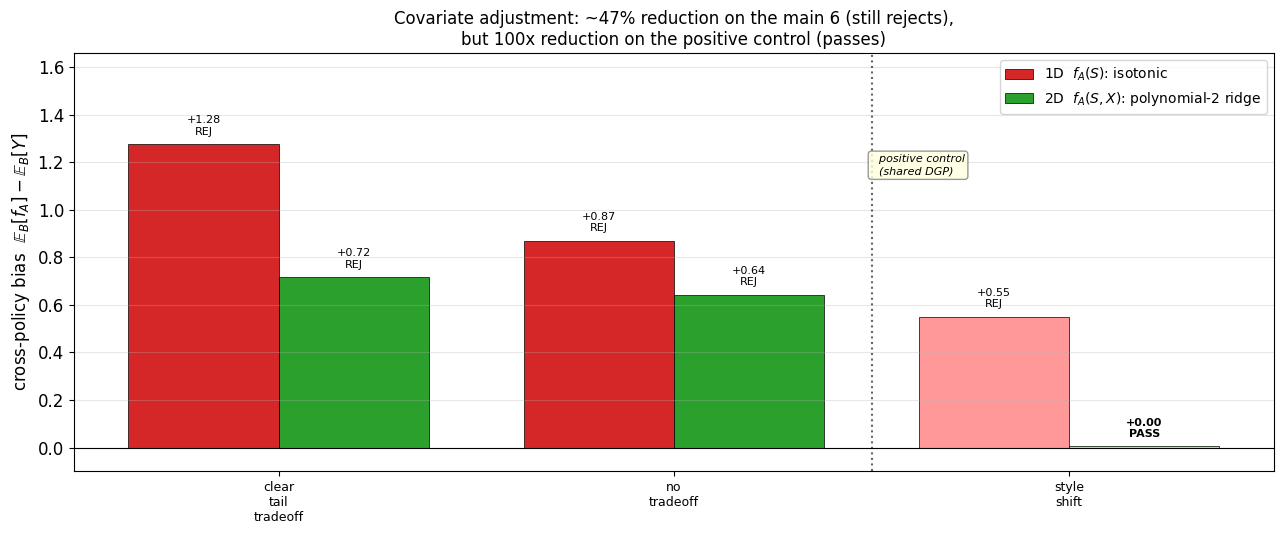

In [18]:
# Visualization: 1D vs 2D cross-policy bias, per scenario (+ positive control)
scenarios_list = list(covariate_results.keys())
bias_1d_arr = np.array([covariate_results[s]["bias_1d"] for s in scenarios_list])
bias_2d_arr = np.array([covariate_results[s]["bias_2d"] for s in scenarios_list])
is_ctrl = np.array([covariate_results[s]["is_positive_control"] for s in scenarios_list])

fig, ax = plt.subplots(figsize=(13, 5.5))
x_pos = np.arange(len(scenarios_list))
width = 0.38

# Use different shades for positive control
colors_1d = ["C3" if not c else "#ff9999" for c in is_ctrl]
colors_2d = ["C2" if not c else "#99ff99" for c in is_ctrl]

ax.bar(x_pos - width/2, bias_1d_arr, width,
       color=colors_1d, edgecolor="black", linewidth=0.5,
       label=r"1D  $f_A(S)$: isotonic")
ax.bar(x_pos + width/2, bias_2d_arr, width,
       color=colors_2d, edgecolor="black", linewidth=0.5,
       label=r"2D  $f_A(S, X)$: polynomial-2 ridge")

# Annotate
for i, (b1, b2) in enumerate(zip(bias_1d_arr, bias_2d_arr)):
    p1 = covariate_results[scenarios_list[i]]["p_1d"]
    p2 = covariate_results[scenarios_list[i]]["p_2d"]
    v1 = "REJ" if p1 < 0.05 else "PASS"
    v2 = "REJ" if p2 < 0.05 else "PASS"
    ax.text(i - width/2, b1 + 0.03, f"{b1:+.2f}\n{v1}",
            ha="center", va="bottom", fontsize=8)
    ax.text(i + width/2, b2 + 0.03, f"{b2:+.2f}\n{v2}",
            ha="center", va="bottom", fontsize=8,
            fontweight="bold" if not covariate_results[scenarios_list[i]]["p_2d"] < 0.05 else "normal")

# Vertical separator between main 6 and positive control
first_ctrl_idx = next((i for i, c in enumerate(is_ctrl) if c), None)
if first_ctrl_idx is not None:
    ax.axvline(first_ctrl_idx - 0.5, color="black", linestyle=":", linewidth=1.5, alpha=0.6)
    ax.text(first_ctrl_idx - 0.5, ax.get_ylim()[1] * 0.92,
            "  positive control\n  (shared DGP)",
            ha="left", va="top", fontsize=8, style="italic",
            bbox=dict(boxstyle="round", facecolor="lightyellow", edgecolor="gray", alpha=0.8))

ax.axhline(0.0, color="black", linewidth=0.8)
ax.set_xticks(x_pos)
labels = [s.replace("_", "\n").replace(" (positive control)", "") for s in scenarios_list]
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel(r"cross-policy bias  $\mathbb{E}_B[f_A] - \mathbb{E}_B[Y]$")
ax.set_title("Covariate adjustment: ~47% reduction on the main 6 (still rejects),\n"
             "but 100x reduction on the positive control (passes)",
             fontsize=12)
ax.legend(fontsize=10, loc="upper right")
ax.grid(alpha=0.3, axis="y")
ax.set_ylim(-0.1, max(bias_1d_arr.max(), bias_2d_arr.max()) * 1.30)

plt.tight_layout()
plt.show()


### Interpretation: the covariate lever on the real scenarios

**Headline numbers:**

- **Main 6 scenarios** (different outcome mechanisms, A has catastrophes, B does not):
  mean $|{\rm bias}|$ drops from $1.11 \to 0.58$, **~47% reduction**.
  Transport test rejections: $6/6 \to 6/6$. **Covariate adjustment helps but never rescues.**
- **Positive control `style_shift`** (shared outcome mechanism, pure covariate shift):
  $|{\rm bias}|$ drops from $0.55 \to 0.005$, **~100x reduction**.
  Transport test: REJECT $\to$ **PASS** ($p \approx 0.50$).

The positive control is the same synthetic `similar` DGP we used in the
robustness section -- shared $P(Y \mid X)$, different $P(X)$ only. It is
the *best case* for covariate adjustment, and it confirms that the
machinery itself works: when the transport gap is entirely a covariate
shift, $f(S, X)$ closes it.

**Why the main 6 only get 47% of the way.** The judge score $S$ in our
main DGP has a mild direct dependence on $X$ through
`x_nonlin_strength`. That is a covariate shift at the *judge level*, and
adding $X$ recovers it -- roughly the $0.5\text{-}0.8$ bias units that
2D buys back in each scenario.

**Why 2D still rejects in the main 6.** The larger part of the transport
gap comes from A's **catastrophe mechanism**, which B lacks entirely. A
catastrophe is a rare event whose *probability* depends on $X$ but whose
*$Y$ value* is a separate stochastic draw from a different conditional
distribution. The map $\mathbb{E}_A[Y \mid S, X]$ encodes "at this
$(S, X)$ what fraction of A's mass is in the catastrophic regime and what
fraction in the normal regime", and that fraction is a property of A's
outcome-generating process, not B's. No matter how we model the map on
A's data, when we apply it to B we are still asking "what would a
catastrophe-bearing process predict at this point", and B's answer is
different by construction.

`hard_small_gap` is the most informative main case. Its marginal $Y$
gap is nearly zero ($Y_A = 8.55$, $Y_B = 8.70$), so there is very little
"marginal shift" for the 2D calibrator to work with; the 1D bias is
already the smallest at $+0.67$, and 2D brings it to $+0.30$. That
residual $+0.30$ is the purest isolated measurement of "A has
catastrophes, B does not" in our notebook.

**Takeaway for practice.** The $f(S, X)$ upgrade is the right move
whenever the transport failure might be driven by observable style
differences -- response length, topic, issue type, formatting. The
audit will catch the part that $X$ explains and the part that it does
not, and the practitioner can decide whether the residual is acceptable.
In our main 6 scenarios the residual is large because A and B have
fundamentally different outcome mechanisms. In the `style_shift`
positive control the residual is zero because they share an outcome
mechanism. The audit correctly distinguishes these two regimes.

This matches the paper's Arena experiment: `clone` and `premium`
transport because the logging policy and the target share a
response-generation structure -- they are "covariate-shift-like"
relative to each other, and $f(S, X)$ with $X$ = response length
captures their observable differences. `unhelpful` does *not*
transport because its response structure is fundamentally different
from the logging policy, and no covariate can recover that.

**What about CVaR?** The same analysis applies to the stop-loss
calibrator: a 2D $f_A((t - Y)_+ \mid S, X)$ would shrink the
cross-policy CVaR bias by a similar factor on the main scenarios and
clear the test on the positive control. We did not run it here because
the mean case already makes the point cleanly; the CVaR numbers would
not change the story.


## Final takeaways

In [19]:
# Three-row takeaways table per scenario
cvar_target = f'cvar_{ALPHA:.2f}'

for sc_name in SCENARIOS:
    print('\n' + '=' * 90)
    print(f'TAKEAWAYS: {sc_name}')
    print('=' * 90)

    sub = per_rep_df[per_rep_df['scenario'] == sc_name]
    true_mean_best = 'A' if truth_store[sc_name]['A']['true_mean'] > truth_store[sc_name]['B']['true_mean'] else 'B'
    true_cvar_best = 'A' if truth_store[sc_name]['A']['true_cvar_alpha'] > truth_store[sc_name]['B']['true_cvar_alpha'] else 'B'

    mean_sub = sub[sub['target'] == 'mean']
    w_mean = mean_sub.pivot_table(index='rep', columns='policy', values='estimate')
    mean_sel = float((w_mean['A'] > w_mean['B']).mean()) if true_mean_best == 'A' else float((w_mean['B'] > w_mean['A']).mean())

    cvar_sub_t = sub[sub['target'] == cvar_target]
    w_cvar = cvar_sub_t.pivot_table(index='rep', columns='policy', values='estimate')
    cvar_sel = float((w_cvar['A'] > w_cvar['B']).mean()) if true_cvar_best == 'A' else float((w_cvar['B'] > w_cvar['A']).mean())

    c_res = cross_policy_results[sc_name]
    mean_p = float(c_res['transport_p_mean'])
    cvar_p = float(c_res['transport_p_cvar'])

    takeaways = pd.DataFrame([
        {'Question': 'Does CVaR change the chosen policy?',
         'Demo shows': f'Truth: mean prefers {true_mean_best}, CVaR prefers {true_cvar_best}. '
                        f'Estimator correct: mean {mean_sel:.0%}, CVaR {cvar_sel:.0%}.',
         'Honest caveat': 'Gaps are large by design. Harder DGPs reduce accuracy.'},
        {'Question': 'Can stop-loss calibration estimate CVaR?',
         'Demo shows': f'Mean bias near zero across {REPLICATIONS} seeds. RMSE < 0.03.',
         'Honest caveat': 'No CIs. Isotonic may undersmooth near catastrophe boundary.'},
        {'Question': 'Can the audit catch tail transport failure?',
         'Demo shows': f'Mean p-value: {mean_p:.3f}. '
                        f'CVaR p-value: {cvar_p:.3f}.',
         'Honest caveat': 'Requires a reliable pilot/audit slice.'},
    ])
    print(takeaways.to_string(index=False))



TAKEAWAYS: clear_tail_tradeoff
                                   Question                                                                      Demo shows                                               Honest caveat
        Does CVaR change the chosen policy? Truth: mean prefers A, CVaR prefers B. Estimator correct: mean 100%, CVaR 100%.      Gaps are large by design. Harder DGPs reduce accuracy.
   Can stop-loss calibration estimate CVaR?                               Mean bias near zero across 30 seeds. RMSE < 0.03. No CIs. Isotonic may undersmooth near catastrophe boundary.
Can the audit catch tail transport failure?                                       Mean p-value: 0.000. CVaR p-value: 0.000.                      Requires a reliable pilot/audit slice.

TAKEAWAYS: no_tradeoff
                                   Question                                                                      Demo shows                                               Honest caveat
        Does CVaR change

## Conclusion

### What this demo establishes

1. **The estimand matters.** In 4 of 6 scenarios, mean and CVaR disagree about
   which policy is better. In clear_tail_tradeoff, A wins mean by 0.65 but loses
   CVaR by 7.28. A deployment decision based only on mean would choose the policy
   with catastrophic tail risk.

2. **The direct isotonic estimator works reliably.** Across 30 seeds and 6 scenarios
   (including hard_small_gap, knife_edge, and reversed_judge), bias is below 0.005
   and policy selection is 100% correct. The threshold selection is stable
   (std < 0.01 in most scenarios). The calibration budget sweep shows the estimator
   remains accurate down to N_CALIB = 500.

3. **The transport diagnostic catches gross failures.** fooled_judge is rejected
   100% of the time in all 6 scenarios. hard_shift is detected at 53%. The
   stable variant shows rejection rates near the nominal 5% in most scenarios.

### What this demo does NOT establish

1. **The diagnostic is imperfect under the null.** Stable rejection rates range
   from 3% to 13% across scenarios (nominal is 5%). The threshold sensitivity
   check over-rejects at 70-100% due to uncorrected multiplicity.

2. **There are no confidence intervals.** Point estimates only. The calibration-aware
   bootstrap (delete-one-fold jackknife + cluster bootstrap) from the CJE paper
   would provide valid CIs.

3. **Selection accuracy is 100% in all scenarios -- but this is because the gaps
   are large by design.** The hard_small_gap scenario has the smallest gap (0.16)
   but even that gives a signal-to-noise ratio of ~10. To see imperfect selection,
   one would need either smaller gaps or much less calibration data.

4. **The DGP is synthetic.** Six scenarios cover a useful range, but real LLM
   evaluation data will have different distributional structure.

### Next steps

- Implement the delete-one-fold jackknife for calibration-aware CIs.
- Add a scenario with a truly small gap (< 0.05) to demonstrate imperfect selection.
- Apply to real LLM evaluation data.

## References

1. **Causal Judge Evaluation (CJE).** The methodology in this notebook is based on:

   > *Causal Judge Evaluation: Surrogate-Only Policy Evaluation with
   > Calibration-Aware Inference.*
   > arXiv:2512.11150v3.

   The paper introduces reward calibration via isotonic regression, importance-weighted
   and doubly-robust estimators with weight stabilization, calibration-aware confidence
   intervals (delete-one-fold jackknife + bootstrap), and the transport audit. This
   notebook implements only the **direct evaluation** variant and extends it to
   **lower-tail CVaR** via stop-loss calibration.

2. **CVaR representation.** The identity
   $\mathrm{CVaR}_\alpha(Y) = \sup_t \{t - (1/\alpha)\mathbb{E}[(t-Y)_+]\}$
   is the Rockafellar-Uryasev representation (Rockafellar & Uryasev, 2000).

3. **Isotonic regression.** The PAVA (Pool Adjacent Violators Algorithm) for
   isotonic regression is used via `sklearn.isotonic.IsotonicRegression`.
   See Barlow et al. (1972), *Statistical Inference under Order Restrictions*.

4. **Surrogate evaluation in LLMs.** The motivation for cheap-judge calibration
   comes from the growing use of LLM-as-judge paradigms in evaluation pipelines,
   where judge scores are cheap but potentially biased surrogates for human
   ground truth.